### **DeepSeek Sparse Attention (DSA): End-to-End Mathematical Algorithm**

**Definition:** DeepSeek Sparse Attention (DSA) is a dynamic, hardware-aligned sparse attention mechanism instantiated within the Multi-Head Latent Attention (MLA) architecture. It decouples the selection of relevant history from the computation of attention using a lightweight "Lightning Indexer" and a "Top-k Selector." It is trained via a teacher-student distillation framework to mimic full attention behavior while reducing complexity from $$O(L^2)$$ to $$O(L \cdot k)$$.

---

### **1. Global Definitions & Inputs**

Let the model parameters and input states be defined as follows:

*   **Inputs:**
    *   $$h_t \in \mathbb{R}^{d_{model}}$$: Current query token hidden state at step $$t$$.
    *   $$H_{<t} \in \mathbb{R}^{t-1 \times d_{model}}$$: Historical hidden states (KV cache source).
    *   $$\mathcal{C}_{<t}^{KV} \in \mathbb{R}^{t-1 \times d_{latent}}$$: Compressed KV latent vectors stored in cache (MLA architecture).
*   **Hyperparameters:**
    *   $$H_I$$: Number of Indexer heads.
    *   $$d_I$$: Dimension of Indexer heads.
    *   $$k$$: Number of sparse tokens to select (Sparsity budget).
    *   $$H_A$$: Number of Core Attention heads.
    *   $$d_c$$: Dimension of core attention query/key/value.

---

### **2. Algorithm Stage I: The Lightning Indexer**

The Indexer acts as a coarse-grained filter. It operates in low precision (FP8) with ReLU activation to maximize throughput.

**Input:** Current query hidden state $$h_t$$, Historical Key Cache $$K^I_{<t}$$.

**Step 1: Projection**
Compute the Indexer Query $$q_t^I$$ and retrieve/compute Indexer Keys $$k_s^I$$ for history $$s < t$$.
$$
q_{t,j}^I = h_t W_{Q}^I, \quad \text{where } W_{Q}^I \in \mathbb{R}^{d_{model} \times (H_I \cdot d_I)}
$$
$$
k_{s}^I = h_s W_{K}^I, \quad \text{where } W_{K}^I \in \mathbb{R}^{d_{model} \times d_I} \text{ (Shared across heads)}
$$

**Step 2: Affinity Computation (ReLU-Attention)**
Unlike standard Softmax, the indexer uses a ReLU-based kernel for speed. The score $$I_{t,s}$$ represents the relevance of token $$s$$ to token $$t$$.
$$
I_{t,s} = \sum_{j=1}^{H_I} w_{t,j}^I \cdot \text{ReLU}\left( (q_{t,j}^I)^\top k_s^I \right)
$$
*   $$w_{t,j}^I$$: Learnable scalar weight for head $$j$$.
*   **Optimization:** This operation bypasses the exponential cost of Softmax and is typically executed via block-wise GEMM.

**Output:** Relevance scores $$I_{t,:} \in \mathbb{R}^{t-1}$$.

---

### **3. Algorithm Stage II: Fine-Grained Selection & Loading**

This stage translates theoretical sparsity into hardware-aligned memory access.

**Step 1: Top-k Filtering**
Identify the set of indices $$S_t$$ corresponding to the $$k$$ highest relevance scores.
$$
S_t = \text{Top-kArgs}(I_{t,:}, k) = \{ s \mid \text{Rank}(I_{t,s}) \le k \}
$$

**Step 2: Hardware-Aligned Data Fetching (Triton Kernel Logic)**
DSA is instantiated under MLA (Multi-Head Latent Attention) in MQA (Multi-Query) mode. This means the Key-Value (KV) cache consists of compressed latent vectors $$c_s^{KV}$$.
*   **Memory Layout:** Latent vectors $$c^{KV}$$ are stored contiguously in High Bandwidth Memory (HBM).
*   **Gather Operation:**
$$
    \mathcal{C}_{S_t}^{KV} = \text{Gather}(\mathcal{C}_{<t}^{KV}, \text{indices}=S_t)
$$
    *   *Hardware Note:* This uses a coalesced load kernel. Instead of loading full dense blocks, the kernel loads specific cache lines defined by $$S_t$$ into the GPU SRAM (L1 Cache).

---

### **4. Algorithm Stage III: Core Attention (MLA-MQA)**

The core attention is computed only on the selected sparse tokens. In DeepSeek-V3.2, this uses the Multi-Head Latent Attention (MLA) architecture.

**Input:** Query $$h_t$$, Selected Latent Cache $$\mathcal{C}_{S_t}^{KV}$$.

**Step 1: Query Generation**
Generate the compressed query latent vector $$c_t^Q$$ and split into "Content" ($$q^{A}$$) and "RoPE" ($$q^{R}$$) components.
$$
[q_{t, h}^{A} ; q_{t, h}^{R}] = h_t W_{UQ} \quad \forall h \in [1, H_A]
$$
*   $$q_{t, h}^{A}$$: Content-based query part.
*   $$q_{t, h}^{R}$$: RoPE-carrying query part.

**Step 2: Sparse Key-Value Generation (De-compression)**
For every selected index $$s \in S_t$$, project the loaded latent vector $$c_s^{KV}$$ into the Key components.
$$
k_{s}^{R} = c_s^{KV} W_{UK}^R \quad \text{(RoPE Key component)}
$$
$$
k_{s}^{C} = c_s^{KV} \quad \text{(Content Key component, implicit via projection fusion)}
$$

**Step 3: Attention Score Calculation**
Compute attention scores $$a_{t,s,h}$$ for head $$h$$ only for $$s \in S_t$$.
$$
a_{t,s,h} = \frac{(q_{t, h}^{A})^\top (c_s^{KV} W_{UK}^C) + (q_{t, h}^{R})^\top k_{s}^{R}}{\sqrt{d_k}}
$$
*   **Note:** The term $$c_s^{KV} W_{UK}^C$$ represents the up-projection of the latent vector to the key space. In optimized kernels, $$W_{UK}^C$$ is absorbed into the query projection to reduce FLOPs.

**Step 4: Sparse Attention Output**
Apply Softmax over the sparse domain and aggregate values.
$$
p_{t,s,h} = \text{Softmax}_{s \in S_t}(a_{t,s,h})
$$
$$
u_{t, h} = \sum_{s \in S_t} p_{t,s,h} \cdot (c_s^{KV} W_{UV})
$$
*   $$W_{UV}$$: Projection matrix generating Values from Latent Vectors.

**Output:** Final context vector $$u_t = \text{Concat}(u_{t,1}, \dots, u_{t, H_A}) W_O$$.

---

### **5. Algorithm Stage IV: Training Objectives (Distillation)**

DSA is not heuristic; it is trained to mimic full attention. The training flow switches between two stages.

#### **Condition A: Dense Warm-up**
*   **Goal:** Initialize Indexer to predict dense attention heatmap.
*   **Teacher:** Full Dense Attention distribution $$P_{dense}$$.
*   **Student:** Indexer distribution $$P_{indexer} = \text{Softmax}(I_{t,:})$$.
*   **Loss:**
$$\mathcal{L}_{\text{warmup}} = \sum_t D_{KL}\Big( \text{Norm}(P_{dense}) \parallel \text{Softmax}(I_{t,:}) \Big)
$$

#### **Condition B: Sparse Training**
*   **Goal:** Optimize Indexer and Core model under sparse constraints.
*   **Operation:** The Indexer input is **detached** from the gradient graph ($$h_t.\text{detach}()$$) to prevent instability.
*   **Loss:**
$$
    \mathcal{L}_{\text{sparse}} = \sum_t D_{KL}\Big( P_{dense}[S_t] \parallel \text{Softmax}(I_{t}[S_t]) \Big) + \mathcal{L}_{\text{LLM}}
$$
$$P_{dense}[S_t]$$
: The teacher's probability mass restricted to the selected indices.
*   The core model updates via standard Cross-Entropy Loss ($$\mathcal{L}_{\text{LLM}}$$) using the sparse context.

---

### **6. Summary of Computational Flow**



$$
\begin{aligned}
& \textbf{Input:} \ h_t, \text{Cache}_{<t} \\
& \text{// 1. Lightning Indexing (FP8, ReLU)} \\
& I_{t,:} \leftarrow \sum w \cdot \text{ReLU}(Q^I K^I) \\
& \\
& \text{// 2. Selection} \\
& S_t \leftarrow \text{TopK}(I_{t,:}) \\
& \\
& \text{// 3. Sparse Fetch (MLA Latents)} \\
& \mathbf{C}_{sparse} \leftarrow \text{Fetch}( \text{Cache}_{<t}[S_t] ) \\
& \\
& \text{// 4. Core Attention (MLA)} \\
& \text{AttnScores} \leftarrow \text{RoPE}(Q_{core}, K_{rope}) + Q_{content} K_{content} \\
& \text{Output}_t \leftarrow \text{Softmax}(\text{AttnScores}) \cdot V_{sparse}
\end{aligned}
$$

### **DeepSeek Sparse Attention (DSA) under MLA: End-to-End Mathematical Algorithm**

**Definition:** DeepSeek Sparse Attention (DSA) is a dynamic sparse attention mechanism instantiated within the Multi-Head Latent Attention (MLA) framework. It reduces computational complexity from $$O(L^2)$$ to $$O(L \cdot k)$$ by using a lightweight "Lightning Indexer" to select relevant history before the heavy core attention computation. The architecture operates in **Multi-Query Attention (MQA) mode**, where compressed latent Key-Value vectors are shared across all query heads to maximize memory bandwidth.

---

### **1. Global Input Definitions**

Let the sequence length be $$t$$ and the sparsity budget be $$k$$.
*   **Input Hidden State:** $$h_t \in \mathbb{R}^{d_{model}}$$ (Current token).
*   **Historical States:** $$h_s \in \mathbb{R}^{d_{model}}$$ for $$s < t$$ (Past tokens).
*   **Latent Cache:** $$\mathcal{C}_{<t}^{KV} \in \mathbb{R}^{(t-1) \times d_{latent}}$$ (Compressed KV vectors stored in cache).

---

### **2. Stage I: Lightning Indexer (The "Green Part")**

The indexer is a lightweight auxiliary module (typically FP8) that predicts the relevance of historical tokens to the current query.

**Step 1: Indexer Projection**
Project the input $$h_t$$ into Indexer Queries ($$q^I$$) and Indexer Keys ($$k^I$$). Note that $$k_s^I$$ is derived from history $$h_s$$ and cached.
$$
q_{t,j}^I = h_t W_{Q}^I \quad \text{where } j \in \{1, \dots, H_I\}
$$
$$
k_{s}^I = h_s W_{K}^I \quad \text{(Shared Key for Indexer)}
$$

**Step 2: ReLU-Based Affinity Scoring**
Compute the relevance score $$I_{t,s}$$ using a ReLU activation instead of Softmax for computational efficiency.
$$
I_{t,s} = \sum_{j=1}^{H_I} w_{t,j}^I \cdot \text{ReLU}\left( (q_{t,j}^I)^\top k_s^I \right)
$$
*   $$w_{t,j}^I$$: Learnable scalar weight for indexer head $$j$$.
*   **Partially Apply RoPE:** Rotary Positional Embeddings are applied to $$q^I$$ and $$k^I$$ before the dot product to capture relative positions.

---

### **3. Stage II: Top-k Selection & Data Fetching**

This stage filters the history based on the Indexer scores and retrieves the heavy MLA latent vectors.

**Step 1: Top-k Filtering**
Identify the indices $$S_t$$ of the $$k$$ most relevant historical tokens.
$$
S_t = \text{Top-kArgs}(I_{t,:}, k) = \{ s \mid \text{Rank}(I_{t,s}) \le k \}
$$

**Step 2: Sparse Latent Gathering**
Retrieve the compressed latent KV vectors $$c_s^{KV}$$ from the main cache corresponding to the selected indices $$S_t$$.
$$
\mathbf{C}_{S_t}^{KV} = \{ c_s^{KV} \mid s \in S_t \}
$$
*   **Hardware Note:** In MQA mode, this single set of latent vectors is shared across *all* core attention heads for the current token $$t$$.

---

### **4. Stage III: Core MLA Attention (MQA Mode)**

The core attention is computed only on the sparse subset $$S_t$$. In MLA, Keys and Values are decoupled projections of the compressed latent vector.

**Step 1: Core Query Generation**
Project $$h_t$$ into the compressed query latent $$c_t^Q$$ and up-project to generate "Content" ($$q^A$$) and "RoPE" ($$q^R$$) components for all $$H_A$$ heads.
$$
c_t^Q = h_t W_{DQ}
$$
$$
[q_{t,i}^A ; q_{t,i}^R] = c_t^Q W_{UQ}^i \quad \forall i \in \{1, \dots, H_A\}
$$

**Step 2: Sparse Key Generation (On-the-Fly)**
For every selected historical token $$s \in S_t$$, generate the RoPE-carrying Key component ($$k_s^R$$). The Content Key is implicitly handled via matrix absorption.
$$
k_s^R = c_s^{KV} W_{UK}^R
$$

**Step 3: Attention Score Calculation**
Compute attention scores $$a_{t,s,i}$$ for head $$i$$ and selected token $$s$$.
$$
a_{t,s,i} = \frac{(q_{t,i}^A)^\top (c_s^{KV} W_{UK}^C) + (q_{t,i}^R)^\top k_s^R}{\sqrt{d_k}}
$$
*   $$W_{UK}^C$$: Up-projection for Content Key (often fused into Query projection for optimization).
*   $$k_s^R$$: RoPE Key component carrying positional information.

**Step 4: Output Aggregation**
Apply Softmax over the sparse domain $$S_t$$ and compute the weighted sum of Values.
$$
p_{t,s,i} = \text{Softmax}_{s \in S_t}(a_{t,s,i})
$$
$$
u_{t,i} = \sum_{s \in S_t} p_{t,s,i} \cdot (c_s^{KV} W_{UV})
$$
*   **MQA Property:** The projection $$W_{UV}$$ (Up-projection for Values) is applied to the *same* shared latent vector $$c_s^{KV}$$, but the attention weights $$p_{t,s,i}$$ differ per head.

**Final Output:**
$$
u_t = \text{Concat}(u_{t,1}, \dots, u_{t,H_A}) W_O
$$

---

### **5. Summary of Computational Flow**

$$
\begin{aligned}
& \textbf{Input:} \ h_t, \text{History}_{<t} \\
& \\
& \text{// 1. Lightning Indexer (Green Part)} \\
& I_{t,s} \leftarrow \sum w \cdot \text{ReLU}(\text{RoPE}(Q^I) \cdot \text{RoPE}(K^I)) \\
& \\
& \text{// 2. Sparse Selection} \\
& S_t \leftarrow \text{TopK}(I_{t,:}) \\
& \mathbf{C}_{sparse} \leftarrow \text{Fetch}( \mathcal{C}_{<t}^{KV}[S_t] ) \\
& \\
& \text{// 3. Core Attention (MLA-MQA)} \\
& Q_{core} \leftarrow \text{UpProject}(h_t) \\
& K_{sparse}^R \leftarrow \text{UpProject}(\mathbf{C}_{sparse}) \\
& \text{Scores} \leftarrow (Q_{content} \cdot \mathbf{C}_{sparse} W^C) + (Q_{rope} \cdot K_{sparse}^R) \\
& \text{Output} \leftarrow \text{Softmax}(\text{Scores}) \cdot (\mathbf{C}_{sparse} W^{V})
\end{aligned}
$$

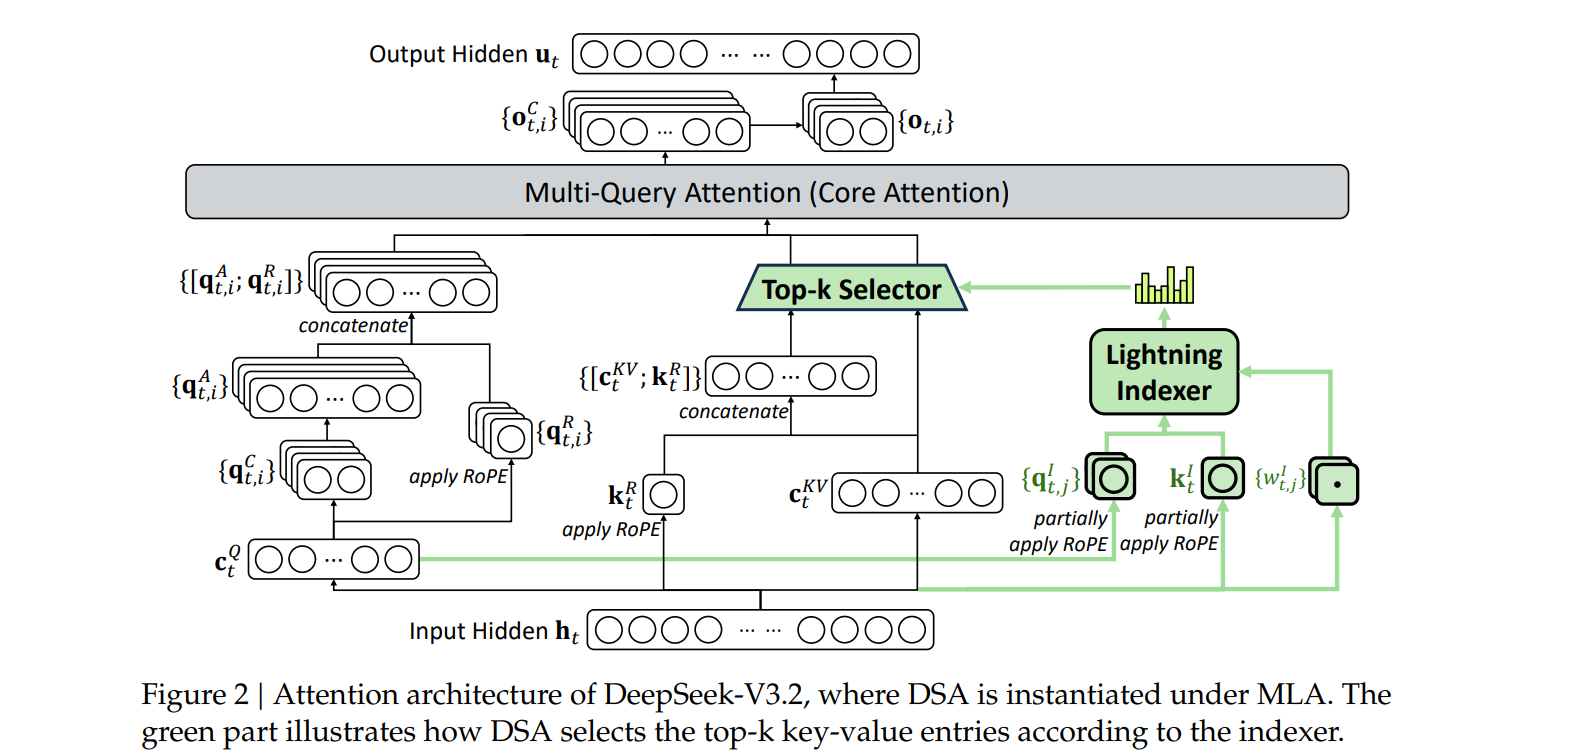

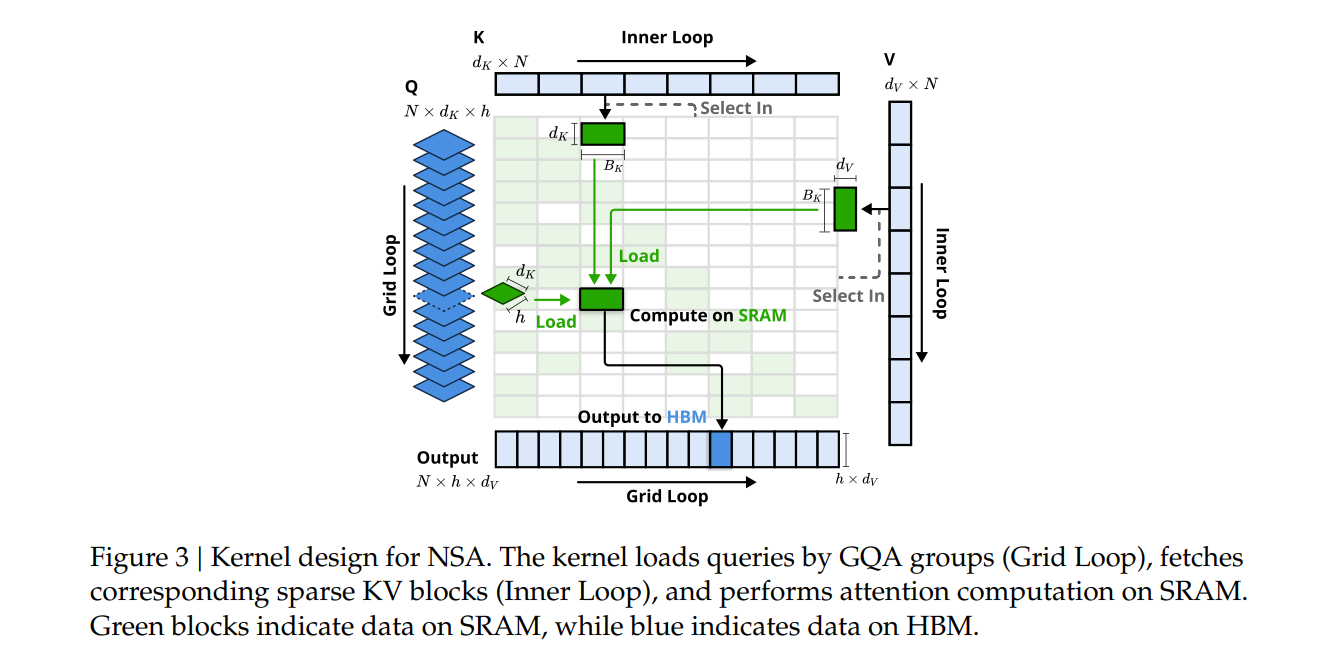



# DeepSeek Sparse Attention (DSA) — Native Sparse Attention: Hardware-Aligned and Natively Trainable Sparse Attention

---

## 1. Formal Definition & Problem Statement

### 1.1 Definition

**DeepSeek Sparse Attention (DSA)**, formally termed **Native Sparse Attention (NSA)**, is a hierarchical, dynamically-routed, hardware-aligned sparse attention mechanism designed for autoregressive Transformer architectures. It replaces full quadratic self-attention with a three-branch system — **token-block compression**, **learned block selection**, and **sliding window** — unified through a gated aggregation layer. DSA is architecturally instantiated within the **Multi-Head Latent Attention (MLA)** framework of DeepSeek-V3, operating over compressed latent KV representations rather than full key-value pairs. It is **natively trainable end-to-end** via a teacher-student distillation protocol that teaches the sparse selection mechanism to approximate the information-routing behavior of full dense attention.

### 1.2 Problem Formulation

Standard scaled dot-product self-attention for a sequence of length $L$ with hidden dimension $d$ computes:

$$
\text{Attn}(Q, K, V) = \text{Softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

This yields:
- **Compute complexity**: $O(L^2 \cdot d)$ FLOPs
- **Memory complexity**: $O(L^2)$ for the attention matrix, $O(L \cdot d)$ for KV cache

For context lengths $L \geq 64\text{K}$, these costs dominate both training throughput and inference latency. Empirically, however, the attention matrix $A \in \mathbb{R}^{L \times L}$ is **approximately sparse**: for each query token $t$, the attention mass concentrates on a small subset $|S_t| = k \ll L$ of key positions. This motivates replacing dense attention with a mechanism that:

1. **Identifies** the critical subset $S_t$ cheaply (sub-quadratic cost).
2. **Computes** exact attention only over $S_t$ (reducing cost to $O(L \cdot k \cdot d)$).
3. **Aligns** memory access patterns to GPU hardware (coalesced block loads, not scattered token fetches).
4. **Trains natively** — learns the selection function jointly with model parameters, not as a post-hoc approximation.

### 1.3 Information-Theoretic Justification

Let $P_{\text{dense}}(s \mid t)$ denote the full attention distribution for query $t$. Define the **effective support** as:

$$
\mathcal{S}_\epsilon(t) = \left\{ s : P_{\text{dense}}(s \mid t) \geq \frac{\epsilon}{L} \right\}
$$

Empirical analysis across Transformer LLMs reveals that $|\mathcal{S}_\epsilon(t)| \ll L$ for practical $\epsilon$, and the entropy of the attention distribution satisfies:

$$
H(P_{\text{dense}}(\cdot \mid t)) \ll \log L
$$

This **low intrinsic dimensionality** of attention patterns guarantees that a sparse approximation $\hat{P}$ supported on $k$ tokens can achieve bounded KL divergence from $P_{\text{dense}}$, provided the selection mechanism identifies the correct support.

---

## 2. Notation, Inputs & Hyperparameters

### 2.1 Symbol Table

| Symbol | Domain | Description |
|--------|--------|-------------|
| $L$ | $\mathbb{Z}^+$ | Sequence length |
| $d_{\text{model}}$ | $\mathbb{Z}^+$ | Model hidden dimension |
| $d_{\text{latent}}$ | $\mathbb{Z}^+$ | MLA latent dimension ($d_{\text{latent}} \ll d_{\text{model}}$) |
| $h_t$ | $\mathbb{R}^{d_{\text{model}}}$ | Hidden state at position $t$ |
| $c_s^{KV}$ | $\mathbb{R}^{d_{\text{latent}}}$ | Compressed KV latent vector at position $s$ (MLA cache) |
| $H_I$ | $\mathbb{Z}^+$ | Number of indexer heads |
| $d_I$ | $\mathbb{Z}^+$ | Dimension per indexer head |
| $H_A$ | $\mathbb{Z}^+$ | Number of core attention heads |
| $d_c$ | $\mathbb{Z}^+$ | Dimension per core attention head |
| $k$ | $\mathbb{Z}^+$ | Sparsity budget (number of selected blocks) |
| $l$ | $\mathbb{Z}^+$ | Block size (tokens per block, hardware-aligned) |
| $w$ | $\mathbb{Z}^+$ | Sliding window size |
| $B$ | $\mathbb{Z}^+$ | Number of blocks: $B = \lceil L / l \rceil$ |

### 2.2 Inputs

$$
\textbf{Inputs:} \quad h_t \in \mathbb{R}^{d_{\text{model}}}, \quad \mathcal{C}_{<t}^{KV} = \{c_1^{KV}, c_2^{KV}, \ldots, c_{t-1}^{KV}\} \subset \mathbb{R}^{d_{\text{latent}}}
$$

### 2.3 Output

$$
\textbf{Output:} \quad o_t \in \mathbb{R}^{d_{\text{model}}} \quad \text{(contextualized representation for position } t\text{)}
$$

---

## 3. Architectural Overview — Three-Branch Design

DSA decomposes the attention computation into three complementary branches, each capturing a different scope of contextual information:

$$
o_t = g_t^{\text{cmp}} \odot o_t^{\text{cmp}} + g_t^{\text{slc}} \odot o_t^{\text{slc}} + g_t^{\text{win}} \odot o_t^{\text{win}}
$$

| Branch | Symbol | Scope | Purpose |
|--------|--------|-------|---------|
| **Compression** | $o_t^{\text{cmp}}$ | All $B$ blocks (coarse) | Global context via compressed block representations |
| **Selection** | $o_t^{\text{slc}}$ | Top-$k$ blocks (fine-grained) | Precise retrieval of critical tokens |
| **Sliding Window** | $o_t^{\text{win}}$ | Last $w$ tokens | Local continuity and recency bias |

The gating weights $g_t^{(\cdot)} \in \mathbb{R}^{d_{\text{model}}}$ are computed from $h_t$ via a learned linear projection followed by sigmoid activation:

$$
[g_t^{\text{cmp}}; g_t^{\text{slc}}; g_t^{\text{win}}] = \sigma\!\left(h_t W_G\right), \quad W_G \in \mathbb{R}^{d_{\text{model}} \times 3d_{\text{model}}}
$$

**Rationale:** The compression branch provides a coarse global "map" of the entire context. The selection branch zooms into the most important regions. The sliding window ensures that local syntactic and semantic patterns are never lost. The gating layer learns to dynamically balance these three signals per token.

---

## 4. Algorithm Stage I: Token-Block Compression

### 4.1 Block Partitioning

Partition the historical sequence $\{1, 2, \ldots, t-1\}$ into contiguous, non-overlapping blocks of size $l$:

$$
\mathcal{B}_b = \{(b-1)l + 1, \; (b-1)l + 2, \; \ldots, \; b \cdot l\}, \quad b \in \{1, 2, \ldots, B\}
$$

where $B = \lfloor (t-1) / l \rfloor$. The block size $l$ is chosen to match the GPU SRAM tile size (typically $l \in \{32, 64, 128\}$) to ensure each block corresponds to exactly one coalesced memory transaction.

### 4.2 Compression Function

For each block $b$, compress the constituent latent vectors into a single block-level representation $\bar{c}_b^{KV}$:

$$
\bar{c}_b^{KV} = f_{\text{compress}}\!\left(\{c_s^{KV}\}_{s \in \mathcal{B}_b}\right)
$$

**Option A — Mean Pooling (parameter-free):**

$$
\bar{c}_b^{KV} = \frac{1}{l} \sum_{s \in \mathcal{B}_b} c_s^{KV}
$$

**Option B — Learned Compression (parameterized):**

$$
\bar{c}_b^{KV} = \text{LayerNorm}\!\left(\frac{1}{l} \sum_{s \in \mathcal{B}_b} \alpha_s \cdot c_s^{KV}\right), \quad \alpha_s = \text{Softmax}_{s \in \mathcal{B}_b}\!\left(c_s^{KV} w_\alpha\right)
$$

where $w_\alpha \in \mathbb{R}^{d_{\text{latent}}}$ is a learned projection vector that produces intra-block attention weights.

### 4.3 Compressed Key-Value Generation

From each $\bar{c}_b^{KV}$, generate compressed keys and values:

$$
\bar{k}_b = \bar{c}_b^{KV} W_{\bar{K}} \in \mathbb{R}^{d_c}, \qquad \bar{v}_b = \bar{c}_b^{KV} W_{\bar{V}} \in \mathbb{R}^{d_c}
$$

The compressed attention output for query $t$ is:

$$
o_t^{\text{cmp}} = \sum_{b=1}^{B} \text{Softmax}_b\!\left(\frac{q_t^\top \bar{k}_b}{\sqrt{d_c}}\right) \cdot \bar{v}_b
$$

**Complexity:** $O(B \cdot d_c) = O\!\left(\frac{L}{l} \cdot d_c\right)$ — linear in $L$.

---

## 5. Algorithm Stage II: Lightning Indexer (Coarse Scoring)

The Lightning Indexer is a lightweight, low-precision scoring module that assigns a relevance score to each block. It operates independently from (and in parallel with) the compression branch.

### 5.1 Indexer Projections

Compute indexer queries from the current hidden state and indexer keys from the block-compressed representations:

$$
q_{t,j}^I = h_t \, W_{Q,j}^I \in \mathbb{R}^{d_I}, \quad j \in \{1, \ldots, H_I\}
$$

$$
\bar{k}_b^I = \bar{c}_b^{KV} W_K^I \in \mathbb{R}^{d_I} \quad \text{(shared across all indexer heads)}
$$

where:
- $W_{Q,j}^I \in \mathbb{R}^{d_{\text{model}} \times d_I}$: Per-head query projection for indexer head $j$.
- $W_K^I \in \mathbb{R}^{d_{\text{latent}} \times d_I}$: Shared key projection (multi-query style for the indexer).

**Design choice — shared keys:** The indexer keys are shared across all $H_I$ heads. This follows the multi-query attention (MQA) paradigm, reducing the indexer KV cache to $O(B \cdot d_I)$ rather than $O(B \cdot H_I \cdot d_I)$. Each head contributes a different "query perspective" while reusing the same key representation.

### 5.2 ReLU-Kernel Affinity Computation

Unlike standard attention which uses the exponential kernel (via Softmax), the indexer employs a **ReLU activation** as its kernel function:

$$
I_{t,b} = \sum_{j=1}^{H_I} w_{t,j}^I \cdot \text{ReLU}\!\left( (q_{t,j}^I)^\top \bar{k}_b^I \right)
$$

where $w_{t,j}^I \in \mathbb{R}$ is a **learnable, input-dependent scalar weight** for head $j$:

$$
w_{t,j}^I = (h_t \, W_w^I)_j, \quad W_w^I \in \mathbb{R}^{d_{\text{model}} \times H_I}
$$

**Why ReLU instead of Softmax:**

| Property | Softmax Kernel | ReLU Kernel |
|----------|---------------|-------------|
| Normalization | Global (requires full pass) | Unnormalized (element-wise) |
| Sparsity | Dense output | Naturally sparse (negative scores → 0) |
| Gradient flow | Saturates for extreme logits | Linear for positive region |
| Computational cost | $O(B)$ with reduction | $O(B)$ embarrassingly parallel |
| Hardware suitability | Requires online softmax | Pure GEMM + element-wise ReLU |
| Precision requirement | FP16/FP32 for numerical stability | FP8-compatible (no exp overflow) |

The ReLU kernel produces exactly zero for irrelevant blocks (negative dot product), providing **intrinsic sparsity** that amplifies the subsequent Top-$k$ selection quality.

### 5.3 FP8 Execution

The entire indexer computation — projections, dot products, ReLU — is executed in **FP8 (E4M3)** precision:

$$
q_{t,j}^I = \text{CastFP8}(h_t) \cdot \text{CastFP8}(W_{Q,j}^I)
$$

This halves memory bandwidth and quadruples throughput on NVIDIA Hopper (H100) SM90 Tensor Cores compared to FP16, making the indexer's overhead negligible relative to core attention.

**Output:** Block relevance scores $I_t = [I_{t,1}, I_{t,2}, \ldots, I_{t,B}] \in \mathbb{R}^B$.

---

## 6. Algorithm Stage III: Hardware-Aligned Block Selection & Fetching

### 6.1 Top-$k$ Block Selection

Identify the $k$ most relevant block indices:

$$
\mathcal{B}_t^* = \underset{|\mathcal{S}| = k}{\arg\max} \sum_{b \in \mathcal{S}} I_{t,b} = \text{TopKIndices}(I_t, k)
$$

### 6.2 Token-Level Index Expansion

Expand selected block indices to the constituent token indices:

$$
S_t = \bigcup_{b \in \mathcal{B}_t^*} \mathcal{B}_b = \bigcup_{b \in \mathcal{B}_t^*} \{(b-1)l + 1, \ldots, b \cdot l\}
$$

$$
|S_t| = k \cdot l
$$

**Hardware alignment guarantee:** Each selected block $\mathcal{B}_b$ maps to a contiguous segment of $l \cdot d_{\text{latent}}$ bytes in HBM. Loading block $b$ requires exactly $\lceil l \cdot d_{\text{latent}} / \text{cache\_line\_size} \rceil$ coalesced memory transactions — no scattered reads, no warp divergence.

### 6.3 Coalesced Gather from KV Cache

$$
\mathcal{C}_{S_t}^{KV} = \text{BlockGather}\!\left(\mathcal{C}_{<t}^{KV}, \; \mathcal{B}_t^*\right) \in \mathbb{R}^{(k \cdot l) \times d_{\text{latent}}}
$$

**Implementation detail:** The `BlockGather` operation is implemented as a custom Triton kernel that:
1. Maps each selected block index $b$ to its HBM base address: $\text{addr}_b = \text{base} + b \cdot l \cdot d_{\text{latent}} \cdot \text{sizeof(dtype)}$.
2. Issues $k$ asynchronous, coalesced `tl.load` operations, each loading $l \times d_{\text{latent}}$ elements.
3. Stores results into a pre-allocated contiguous SRAM buffer for downstream attention computation.

**Contrast with token-level scatter:** A naive token-level Top-$k$ would require $k \cdot l$ independent, potentially non-contiguous loads — up to $k \cdot l$ separate memory transactions vs. $k$ coalesced ones. For $l = 64$, this is a **64× reduction** in memory transaction count.

---

## 7. Algorithm Stage IV: Core MLA Sparse Attention (Selection Branch)

The selection branch computes fine-grained, exact attention over the tokens in $S_t$, using the MLA architecture.

### 7.1 Query Generation (MLA)

The query for position $t$ is generated through a two-stage compression-decompression path:

$$
c_t^Q = h_t \, W_{DQ} \in \mathbb{R}^{d_{\text{latent}}^Q}
$$

$$
[q_{t,h}^C \;;\; \hat{q}_{t,h}^R] = c_t^Q \, W_{UQ,h} \quad \forall h \in \{1, \ldots, H_A\}
$$

where:
- $W_{DQ} \in \mathbb{R}^{d_{\text{model}} \times d_{\text{latent}}^Q}$: Down-projection (compression).
- $W_{UQ,h} \in \mathbb{R}^{d_{\text{latent}}^Q \times (d_c + d_R)}$: Up-projection (decompression) for head $h$.
- $q_{t,h}^C \in \mathbb{R}^{d_c}$: Content query component.
- $\hat{q}_{t,h}^R \in \mathbb{R}^{d_R}$: Pre-RoPE positional query component.

Apply Rotary Position Embedding (RoPE):

$$
q_{t,h}^R = \text{RoPE}(\hat{q}_{t,h}^R, \; t)
$$

### 7.2 Sparse Key-Value De-compression

For each selected position $s \in S_t$, decompress the cached latent $c_s^{KV}$ into key components:

$$
k_s^C = c_s^{KV} W_{UK}^C \in \mathbb{R}^{d_c} \quad \text{(Content key — shared across heads)}
$$

$$
\hat{k}_s^R = c_s^{KV} W_{UK}^R \in \mathbb{R}^{d_R}, \qquad k_s^R = \text{RoPE}(\hat{k}_s^R, \; s)
$$

$$
v_s = c_s^{KV} W_{UV} \in \mathbb{R}^{d_v} \quad \text{(Value — shared across heads)}
$$

**Critical observation:** The de-compression projections ($W_{UK}^C$, $W_{UK}^R$, $W_{UV}$) are applied only to $|S_t| = k \cdot l$ tokens, not to all $t-1$ historical tokens. This is the primary computational saving of sparse attention under MLA — the expensive up-projections are performed on the sparse subset only.

**Kernel fusion optimization:** In practice, $W_{UK}^C$ is absorbed into $W_{UQ,h}$ by defining $\tilde{W}_{UQ,h} = W_{UQ,h} (W_{UK}^C)^\top$, so the content attention score becomes $q_{t,h}^C \cdot k_s^C = (c_t^Q \tilde{W}_{UQ,h}) c_s^{KV\top}$, computing the score directly from latents without materializing full-dimensional keys.

### 7.3 Attention Score Computation

For each head $h$ and selected position $s \in S_t$:

$$
a_{t,s,h} = \frac{(q_{t,h}^C)^\top k_s^C + (q_{t,h}^R)^\top k_s^R}{\sqrt{d_c + d_R}}
$$

The score decomposes into:
- **Content term** $(q_{t,h}^C)^\top k_s^C$: Semantic similarity, position-independent.
- **Positional term** $(q_{t,h}^R)^\top k_s^R$: Relative position encoding via RoPE.

### 7.4 Sparse Softmax & Value Aggregation

$$
p_{t,s,h} = \frac{\exp(a_{t,s,h})}{\displaystyle\sum_{s' \in S_t} \exp(a_{t,s',h})}, \quad s \in S_t
$$

$$
u_{t,h} = \sum_{s \in S_t} p_{t,s,h} \cdot v_s \in \mathbb{R}^{d_v}
$$

**Selection branch output:**

$$
o_t^{\text{slc}} = \text{Concat}(u_{t,1}, \ldots, u_{t,H_A}) \, W_O^{\text{slc}} \in \mathbb{R}^{d_{\text{model}}}
$$

---

## 8. Algorithm Stage V: Sliding Window Attention

The sliding window branch computes standard dense attention over the most recent $w$ tokens:

$$
\mathcal{W}_t = \{\max(1, t - w), \ldots, t - 1\}
$$

This uses the same MLA query-key-value mechanism as Stage IV, but over the fixed local window $\mathcal{W}_t$:

$$
o_t^{\text{win}} = \text{MLA-Attention}(h_t, \; \{c_s^{KV}\}_{s \in \mathcal{W}_t})
$$

**Complexity:** $O(w \cdot d_c \cdot H_A)$ — constant with respect to $L$.

**Rationale:** The sliding window ensures that:
1. **Local syntactic patterns** (adjacent word dependencies, punctuation scope) are always captured.
2. **Attention sink tokens** (e.g., BOS, high-frequency tokens) within the window are never missed.
3. The selection branch can specialize in **long-range retrieval** without being burdened by local patterns.

---

## 9. Algorithm Stage VI: Gated Multi-Branch Aggregation

### 9.1 Gate Computation

$$
[\tilde{g}_t^{\text{cmp}}; \; \tilde{g}_t^{\text{slc}}; \; \tilde{g}_t^{\text{win}}] = h_t \, W_G + b_G
$$

$$
g_t^{(\cdot)} = \sigma(\tilde{g}_t^{(\cdot)}) \in \mathbb{R}^{d_{\text{model}}}
$$

where $\sigma(\cdot)$ denotes the element-wise sigmoid function. The gates operate at the **per-dimension** granularity, allowing different feature dimensions to draw from different branches.

### 9.2 Final Output

$$
o_t = g_t^{\text{cmp}} \odot o_t^{\text{cmp}} + g_t^{\text{slc}} \odot o_t^{\text{slc}} + g_t^{\text{win}} \odot o_t^{\text{win}}
$$

$$
\hat{o}_t = o_t + h_t \quad \text{(Residual connection)}
$$

where $\odot$ denotes element-wise (Hadamard) product.

---

## 10. Algorithm Stage VII: Training via Distillation

DSA is not a heuristic pruning method — it is trained to **faithfully approximate full dense attention** through a structured distillation protocol.

### 10.1 Teacher: Full Dense Attention

For each training token $t$ and head $h$, the teacher produces the full attention distribution:

$$
P_{\text{dense}}^h(s \mid t) = \text{Softmax}_s\!\left(\frac{(q_{t,h}^C)^\top k_s^C + (q_{t,h}^R)^\top k_s^R}{\sqrt{d_c + d_R}}\right), \quad s \in \{1, \ldots, t-1\}
$$

This is computed with full $O(L^2)$ cost during training only (or on a subset of layers/steps).

### 10.2 Phase 1: Dense Warm-Up

**Goal:** Initialize the Lightning Indexer to accurately predict the dense attention's sparsity pattern before introducing any sparsity into the forward pass.

**Student distribution:** Convert indexer scores to a probability distribution for loss computation:

$$
P_{\text{idx}}(b \mid t) = \text{Softmax}_b(I_{t,b})
$$

**Teacher target:** Aggregate dense attention mass per block:

$$
P_{\text{block}}^{\text{dense}}(b \mid t) = \sum_{s \in \mathcal{B}_b} \bar{P}_{\text{dense}}(s \mid t)
$$

where $\bar{P}_{\text{dense}}(s \mid t) = \frac{1}{H_A}\sum_{h=1}^{H_A} P_{\text{dense}}^h(s \mid t)$ is the head-averaged dense distribution.

**Loss:**

$$
\mathcal{L}_{\text{warmup}} = \frac{1}{L} \sum_{t=1}^{L} D_{\text{KL}}\!\left(P_{\text{block}}^{\text{dense}}(\cdot \mid t) \;\|\; P_{\text{idx}}(\cdot \mid t)\right)
$$

$$
= \frac{1}{L} \sum_{t=1}^{L} \sum_{b=1}^{B} P_{\text{block}}^{\text{dense}}(b \mid t) \log \frac{P_{\text{block}}^{\text{dense}}(b \mid t)}{P_{\text{idx}}(b \mid t)}
$$

**Gradient scope:** Only the indexer parameters $\{W_Q^I, W_K^I, W_w^I\}$ are updated. The core attention parameters remain frozen or follow standard pretraining loss.

### 10.3 Phase 2: Sparse Training

**Goal:** Train the full model (indexer + core attention + gating) under actual sparse operation.

**Critical design: Gradient detachment.** The indexer input is detached from the computational graph to prevent sparse selection gradients from destabilizing the backbone hidden state representations:

$$
I_{t,b} = f_{\text{indexer}}(\text{StopGrad}(h_t), \; \bar{c}_b^{KV})
$$

This ensures that the backbone $h_t$ is optimized solely via the language modeling loss through the core attention path, while the indexer parameters are optimized via the distillation loss.

**Indexer distillation loss (on selected support):**

$$
\mathcal{L}_{\text{idx}} = \frac{1}{L} \sum_{t=1}^{L} D_{\text{KL}}\!\left(\text{Renorm}\!\left(P_{\text{block}}^{\text{dense}}(\cdot \mid t)\big|_{\mathcal{B}_t^*}\right) \;\Big\|\; \text{Softmax}\!\left(I_t\big|_{\mathcal{B}_t^*}\right)\right)
$$

where $\text{Renorm}(P|_\mathcal{S})$ re-normalizes the teacher's distribution restricted to the selected blocks $\mathcal{B}_t^*$.

**Language modeling loss:**

$$
\mathcal{L}_{\text{LM}} = -\frac{1}{L} \sum_{t=1}^{L} \log p_\theta(x_t \mid x_{<t})
$$

where the conditional probability is computed using the sparse attention output $o_t$.

**Total training loss:**

$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{LM}} + \lambda \cdot \mathcal{L}_{\text{idx}}
$$

where $\lambda > 0$ is a balancing coefficient (typically $\lambda \in [0.1, 1.0]$, annealed during training).

### 10.4 Straight-Through Estimator for Selection Gradients

The Top-$k$ operation is non-differentiable. During the backward pass, the gradient through the selection operation is approximated via the **straight-through estimator (STE)**:

$$
\frac{\partial \mathcal{L}}{\partial I_{t,b}} \approx \frac{\partial \mathcal{L}}{\partial \mathbb{1}[b \in \mathcal{B}_t^*]} \cdot 1
$$

Combined with the detachment strategy, this ensures stable training: the indexer receives gradient signal about *which blocks it should have selected* without propagating noisy discrete gradients into the backbone.

---

## 11. Theoretical Complexity Analysis

### 11.1 FLOPs Per Token (Inference, Single Layer)

| Component | Dense Attention | DSA |
|-----------|:-:|:-:|
| Indexer | — | $O(B \cdot H_I \cdot d_I) = O\!\left(\frac{L}{l} \cdot H_I \cdot d_I\right)$ |
| Top-$k$ Selection | — | $O(B \log k)$ |
| Compression Branch | — | $O(B \cdot d_c \cdot H_A)$ |
| Core Attention (Selection) | $O(L \cdot d_c \cdot H_A)$ | $O(k \cdot l \cdot d_c \cdot H_A)$ |
| Sliding Window | — | $O(w \cdot d_c \cdot H_A)$ |
| De-compression (MLA) | $O(L \cdot d_{\text{latent}} \cdot d_c)$ | $O(k \cdot l \cdot d_{\text{latent}} \cdot d_c)$ |
| **Total** | $O(L \cdot d_c \cdot H_A)$ | $O\!\left(\left(\frac{L}{l}(H_I d_I + d_c H_A) + k l \cdot d_c H_A + w \cdot d_c H_A\right)\right)$ |

For typical hyperparameters ($L = 128\text{K}$, $l = 64$, $k = 16$, $w = 512$, $H_I d_I \ll d_c H_A$):

$$
\text{Effective tokens attended} = \underbrace{\frac{L}{l}}_{\text{compression}} + \underbrace{k \cdot l}_{= 1024} + \underbrace{w}_{= 512} \approx 3{,}584 \quad \ll \quad L = 131{,}072
$$

**Speedup factor:** $\approx \frac{L}{k \cdot l + w + L/l} \approx 36\times$ in attention FLOPs.

### 11.2 Memory Access Volume (HBM Reads Per Token)

| Method | HBM Reads |
|--------|-----------|
| Dense Attention (MLA) | $(t-1) \cdot d_{\text{latent}}$ bytes |
| DSA | $\underbrace{B \cdot d_I}_{\text{indexer keys}} + \underbrace{k \cdot l \cdot d_{\text{latent}}}_{\text{selected latents}} + \underbrace{w \cdot d_{\text{latent}}}_{\text{window latents}}$ bytes |

Since $d_I \ll d_{\text{latent}}$ and $k \cdot l + w \ll L$, DSA achieves a proportional reduction in memory bandwidth consumption, which is the dominant bottleneck during autoregressive decoding.

### 11.3 KV Cache Size (Unchanged)

DSA does **not** reduce the KV cache size — it reduces the **access pattern** per query. The full cache $\mathcal{C}_{<t}^{KV} \in \mathbb{R}^{(t-1) \times d_{\text{latent}}}$ is still stored in HBM. The savings come from reading only $k \cdot l + w$ entries instead of $t - 1$ entries per decoding step.

---

## 12. Complete Pseudo-Algorithm: DSA Inference

```
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ALGORITHM 1: DeepSeek Sparse Attention — Single-Token Inference
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

INPUT:
  h_t ∈ ℝ^{d_model}                — hidden state at current position t
  C_cache ∈ ℝ^{(t-1) × d_latent}   — MLA latent KV cache for positions 1..t-1
  C_idx_cache ∈ ℝ^{B × d_I}        — precomputed indexer key cache (block-compressed)

OUTPUT:
  o_t ∈ ℝ^{d_model}                — contextualized output representation

HYPERPARAMETERS:
  H_I, d_I       — indexer: number of heads, head dimension
  H_A, d_c, d_R  — core attention: heads, content dim, RoPE dim
  k               — sparsity budget (number of blocks)
  l               — block size (hardware-aligned)
  w               — sliding window size

LEARNED PARAMETERS:
  W_Q^I ∈ ℝ^{d_model × (H_I · d_I)},  W_K^I ∈ ℝ^{d_latent × d_I}
  W_w^I ∈ ℝ^{d_model × H_I}
  W_DQ ∈ ℝ^{d_model × d_latent^Q},  W_UQ ∈ ℝ^{d_latent^Q × H_A·(d_c+d_R)}
  W_UK^C ∈ ℝ^{d_latent × d_c},  W_UK^R ∈ ℝ^{d_latent × d_R}
  W_UV ∈ ℝ^{d_latent × d_v}
  W_K_bar ∈ ℝ^{d_latent × d_c},  W_V_bar ∈ ℝ^{d_latent × d_v}
  W_G ∈ ℝ^{d_model × 3·d_model},  W_O ∈ ℝ^{H_A·d_v × d_model}

BEGIN:

  ┌──────────────────────────────────────────────────────┐
  │  STAGE 1: LIGHTNING INDEXER  (FP8, ReLU Kernel)      │
  └──────────────────────────────────────────────────────┘

  1.  B ← ⌊(t - 1) / l⌋

  2.  FOR j = 1 TO H_I:
        q_{t,j}^I ← CastFP8(h_t) · CastFP8(W_{Q,j}^I)      // ∈ ℝ^{d_I}

  3.  w_t^I ← h_t · W_w^I                                    // ∈ ℝ^{H_I}

  4.  FOR b = 1 TO B:
        // Retrieve precomputed indexer key for block b
        k_bar_b^I ← C_idx_cache[b]                            // ∈ ℝ^{d_I}

        // Multi-head ReLU scoring
        I_{t,b} ← Σ_{j=1}^{H_I}  w_{t,j}^I · ReLU( (q_{t,j}^I)^T · k_bar_b^I )

  ┌──────────────────────────────────────────────────────┐
  │  STAGE 2: TOP-k BLOCK SELECTION & FETCH              │
  └──────────────────────────────────────────────────────┘

  5.  B_selected ← TopKIndices(I_t, k)                        // |B_selected| = k

  6.  S_t ← ∅
      FOR EACH b ∈ B_selected:
        S_t ← S_t ∪ {(b-1)·l + 1, ..., b·l}                  // |S_t| = k·l

  7.  C_sparse ← BlockGather(C_cache, B_selected)             // ∈ ℝ^{(k·l) × d_latent}
      // Coalesced HBM → SRAM transfer, k memory transactions

  ┌──────────────────────────────────────────────────────┐
  │  STAGE 3: SLIDING WINDOW FETCH                       │
  └──────────────────────────────────────────────────────┘

  8.  W_t ← {max(1, t - w), ..., t - 1}
  9.  C_window ← C_cache[W_t]                                 // ∈ ℝ^{w × d_latent}
      // Contiguous read — single coalesced transaction

  ┌──────────────────────────────────────────────────────┐
  │  STAGE 4: COMPRESSION BRANCH                         │
  └──────────────────────────────────────────────────────┘

  10. FOR b = 1 TO B:
        c_bar_b ← C_idx_cache[b]  // reuse compressed representations
        k_bar_b ← c_bar_b · W_K_bar                           // ∈ ℝ^{d_c}
        v_bar_b ← c_bar_b · W_V_bar                           // ∈ ℝ^{d_v}

  11. // Query for compression branch (same MLA query)
      c_t^Q ← h_t · W_DQ
      FOR h = 1 TO H_A:
        [q_{t,h}^C ; q_hat_{t,h}^R] ← c_t^Q · W_{UQ,h}
        q_{t,h}^R ← RoPE(q_hat_{t,h}^R, t)

        // Compressed attention (over B blocks)
        FOR b = 1 TO B:
          a_{t,b,h}^cmp ← (q_{t,h}^C)^T · k_bar_b / √d_c
        p_{t,:,h}^cmp ← Softmax(a_{t,:,h}^cmp)               // over b = 1..B
        u_{t,h}^cmp ← Σ_b  p_{t,b,h}^cmp · v_bar_b

  12. o_t^cmp ← Concat(u_{t,1}^cmp, ..., u_{t,H_A}^cmp) · W_O^cmp

  ┌──────────────────────────────────────────────────────┐
  │  STAGE 5: SELECTION BRANCH (Core MLA Sparse Attn)    │
  └──────────────────────────────────────────────────────┘

  13. FOR s ∈ S_t:
        k_s^C ← C_sparse[s] · W_UK^C                         // ∈ ℝ^{d_c}
        k_hat_s^R ← C_sparse[s] · W_UK^R
        k_s^R ← RoPE(k_hat_s^R, s)                            // ∈ ℝ^{d_R}
        v_s ← C_sparse[s] · W_UV                              // ∈ ℝ^{d_v}

  14. FOR h = 1 TO H_A:
        FOR s ∈ S_t:
          a_{t,s,h}^slc ← ((q_{t,h}^C)^T · k_s^C + (q_{t,h}^R)^T · k_s^R) / √(d_c + d_R)
        p_{t,:,h}^slc ← Softmax(a_{t,:,h}^slc)               // over s ∈ S_t
        u_{t,h}^slc ← Σ_{s ∈ S_t}  p_{t,s,h}^slc · v_s

  15. o_t^slc ← Concat(u_{t,1}^slc, ..., u_{t,H_A}^slc) · W_O^slc

  ┌──────────────────────────────────────────────────────┐
  │  STAGE 6: SLIDING WINDOW BRANCH                      │
  └──────────────────────────────────────────────────────┘

  16. // Identical MLA attention over window tokens
      FOR s ∈ W_t:
        k_s^C ← C_window[s] · W_UK^C
        k_s^R ← RoPE(C_window[s] · W_UK^R, s)
        v_s ← C_window[s] · W_UV

  17. FOR h = 1 TO H_A:
        FOR s ∈ W_t:
          a_{t,s,h}^win ← ((q_{t,h}^C)^T · k_s^C + (q_{t,h}^R)^T · k_s^R) / √(d_c + d_R)
        p_{t,:,h}^win ← Softmax(a_{t,:,h}^win)
        u_{t,h}^win ← Σ_{s ∈ W_t}  p_{t,s,h}^win · v_s

  18. o_t^win ← Concat(u_{t,1}^win, ..., u_{t,H_A}^win) · W_O^win

  ┌──────────────────────────────────────────────────────┐
  │  STAGE 7: GATED AGGREGATION                          │
  └──────────────────────────────────────────────────────┘

  19. [g_tilde^cmp ; g_tilde^slc ; g_tilde^win] ← h_t · W_G
      g_t^cmp ← σ(g_tilde^cmp)                                // ∈ ℝ^{d_model}
      g_t^slc ← σ(g_tilde^slc)
      g_t^win ← σ(g_tilde^win)

  20. o_t ← g_t^cmp ⊙ o_t^cmp  +  g_t^slc ⊙ o_t^slc  +  g_t^win ⊙ o_t^win

  RETURN o_t

END
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
```

---

## 13. Complete Pseudo-Algorithm: DSA Training

```
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ALGORITHM 2: DeepSeek Sparse Attention — Training Protocol
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

INPUT:
  X = {x_1, x_2, ..., x_L}    — training sequence
  θ_backbone                    — backbone Transformer parameters
  θ_indexer                     — Lightning Indexer parameters
  θ_gate                        — gating parameters

OUTPUT:
  Updated parameters θ_backbone, θ_indexer, θ_gate

HYPERPARAMETERS:
  T_warmup                      — number of warm-up steps
  λ                             — distillation loss weight
  k, l, w                       — sparsity hyperparameters

BEGIN:

  ┌──────────────────────────────────────────────────────┐
  │  PHASE 1: DENSE WARM-UP  (steps 1 .. T_warmup)      │
  └──────────────────────────────────────────────────────┘

  FOR step = 1 TO T_warmup:

    1. Compute full forward pass with DENSE attention
       // Produces hidden states h_1, ..., h_L and dense attention maps

    2. FOR each position t:
         // Teacher: aggregate dense attention mass per block
         FOR b = 1 TO B:
           P_block_dense(b|t) ← Σ_{s ∈ B_b} (1/H_A) Σ_h P_dense^h(s|t)

         // Student: indexer block-level distribution
         Compute I_{t,b} for all b using Algorithm 1, Stage 1
         P_idx(b|t) ← Softmax_b(I_{t,b})

    3. L_warmup ← (1/L) Σ_t D_KL( P_block_dense(·|t) ‖ P_idx(·|t) )

    4. L_LM ← -(1/L) Σ_t log p(x_t | x_{<t})   // standard LM loss, dense attn

    5. L_total ← L_LM + λ · L_warmup

    6. Update θ_backbone, θ_indexer via ∇L_total
       // Backbone updates via L_LM; Indexer updates via L_warmup + L_LM

  ┌──────────────────────────────────────────────────────┐
  │  PHASE 2: SPARSE TRAINING  (steps T_warmup+1 .. T)  │
  └──────────────────────────────────────────────────────┘

  FOR step = T_warmup + 1 TO T:

    1. Compute backbone hidden states h_1, ..., h_L
       // Standard Transformer forward pass up to current layer

    2. FOR each position t:

         // ── Indexer forward (DETACHED backbone input) ──
         h_t_detached ← StopGradient(h_t)
         Compute I_{t,b} for all b using h_t_detached       // No gradient to backbone
         B_selected_t ← TopKIndices(I_t, k)

         // ── Sparse attention forward (Algorithm 1, Stages 2-7) ──
         o_t ← DSA_Forward(h_t, C_cache, B_selected_t, k, l, w)
         // Gradient flows through o_t → h_t → backbone (via core attention)
         // Gradient does NOT flow through selection indices

    3. // ── Teacher computation (periodic or continuous) ──
       // Option A: Compute dense attention for ALL positions (expensive)
       // Option B: Compute dense attention for SAMPLED positions
       //           (e.g., every 4th position, random 25%)
       FOR sampled position t:
         Compute P_dense^h(s|t) using full dense attention

    4. // ── Indexer distillation loss ──
       FOR sampled position t:
         FOR b ∈ B_selected_t:
           P_teacher_restricted(b|t) ← Renormalize(P_block_dense(b|t))
         P_student_restricted(b|t) ← Softmax(I_{t,b} for b ∈ B_selected_t)
         
       L_idx ← (1/|sampled|) Σ_t D_KL(P_teacher_restricted ‖ P_student_restricted)

    5. // ── Language modeling loss (under sparse attention) ──
       L_LM ← -(1/L) Σ_t log p_sparse(x_t | x_{<t})

    6. // ── Total loss ──
       L_total ← L_LM + λ · L_idx

    7. // ── Gradient computation ──
       ∇θ_backbone L_total  // Gradient from L_LM only (indexer input detached)
       ∇θ_indexer  L_total  // Gradient from L_idx (primary) + STE through TopK
       ∇θ_gate     L_total  // Gradient from L_LM (through gated aggregation)

    8. Update all parameters via optimizer (e.g., AdamW)

       // ── Auxiliary: Update indexer key cache ──
       FOR each new token processed:
         IF token completes a block b:
           c_bar_b ← Compress({c_s^KV}_{s ∈ B_b})
           k_bar_b^I ← c_bar_b · W_K^I
           Store k_bar_b^I in C_idx_cache[b]

END
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
```

---

## 14. Summary: End-to-End Computational Flow

The complete DSA mechanism for a single query token $t$ is summarized as:

$$
\boxed{
\begin{aligned}
& \textbf{Given:} \; h_t,\; \mathcal{C}_{<t}^{KV} \\[6pt]
& \text{1. \textsc{Compress:}} \quad \bar{c}_b \leftarrow \frac{1}{l}\textstyle\sum_{s \in \mathcal{B}_b} c_s^{KV}, \quad b = 1,\ldots,B \\[4pt]
& \text{2. \textsc{Index} (FP8, ReLU):} \quad I_{t,b} \leftarrow \textstyle\sum_{j} w_{t,j}^I \cdot \text{ReLU}\!\left({q_{t,j}^I}^\top \bar{k}_b^I\right) \\[4pt]
& \text{3. \textsc{Select:}} \quad \mathcal{B}_t^* \leftarrow \text{TopK}(I_t,\, k) \\[4pt]
& \text{4. \textsc{Fetch:}} \quad \mathcal{C}_{S_t} \leftarrow \text{BlockGather}(\mathcal{C}_{<t}^{KV},\, \mathcal{B}_t^*) \\[4pt]
& \text{5. \textsc{Attend}_{\text{cmp}}:} \quad o_t^{\text{cmp}} \leftarrow \text{MLA}(h_t,\, \{\bar{c}_b\}_{b=1}^B) \\[4pt]
& \text{6. \textsc{Attend}_{\text{slc}}:} \quad o_t^{\text{slc}} \leftarrow \text{MLA}(h_t,\, \mathcal{C}_{S_t}) \\[4pt]
& \text{7. \textsc{Attend}_{\text{win}}:} \quad o_t^{\text{win}} \leftarrow \text{MLA}(h_t,\, \mathcal{C}_{\mathcal{W}_t}) \\[4pt]
& \text{8. \textsc{Gate \& Merge:}} \quad o_t \leftarrow \sigma(h_t W_G^{\text{cmp}}) \odot o_t^{\text{cmp}} + \sigma(h_t W_G^{\text{slc}}) \odot o_t^{\text{slc}} + \sigma(h_t W_G^{\text{win}}) \odot o_t^{\text{win}}
\end{aligned}
}
$$

**Asymptotic complexity per token:**

$$
O\!\left(\underbrace{\frac{L}{l} \cdot H_I \cdot d_I}_{\text{Indexer}} + \underbrace{\frac{L}{l} \cdot d_c \cdot H_A}_{\text{Compression Attn}} + \underbrace{k \cdot l \cdot d_c \cdot H_A}_{\text{Selection Attn}} + \underbrace{w \cdot d_c \cdot H_A}_{\text{Window Attn}}\right)
$$

For $k \cdot l + w + L/l \ll L$, this achieves effective **sub-quadratic** scaling: $O(L \cdot k)$ overall, replacing the $O(L^2)$ cost of dense attention while preserving approximation fidelity through natively trained, hardware-aligned block selection.



# DeepSeek Sparse Attention (DSA): Native Sparse Attention with Hardware-Aligned, Natively Trainable Sparse Attention

---

## 1. Foundational Definition

**DeepSeek Sparse Attention (DSA)** is a *learned*, *dynamic*, *hardware-aligned* sparse attention mechanism designed to operate natively within the **Multi-Head Latent Attention (MLA)** architectural substrate. Unlike static or heuristic sparse patterns (e.g., sliding window, block-sparse, or fixed stride), DSA introduces a two-stage pipeline:

1. A lightweight **Lightning Indexer** that computes coarse relevance scores over the full history in $O(L)$ time using ReLU-gated affinity with reduced precision (FP8).
2. A **Top-$k$ Selector** that extracts the most relevant $k$ tokens, followed by full-fidelity **Core Attention** computed exclusively over this sparse subset under the MLA decomposition.

The mechanism is trained end-to-end via a **teacher-student distillation framework** where the teacher is the dense (full quadratic) attention distribution, ensuring that the sparse approximation faithfully preserves the information-theoretic content of dense attention while reducing per-step complexity from $O(L^2 \cdot d)$ to $O(L \cdot d_I + k \cdot d_c)$.

**Formal Complexity Statement:**

$$
\mathcal{T}_{\text{DSA}}(L) = \underbrace{O(L \cdot H_I \cdot d_I)}_{\text{Indexer (FP8)}} + \underbrace{O(L \log k)}_{\text{Top-}k\text{ Selection}} + \underbrace{O(k \cdot H_A \cdot d_c)}_{\text{Core MLA Attention}} \ll O(L^2 \cdot d_c)
$$

where $L$ is the sequence length, $k \ll L$ is the sparsity budget, $H_I$ and $H_A$ are the number of indexer and core attention heads respectively, $d_I$ is the indexer head dimension, and $d_c$ is the core attention head dimension.

---

## 2. Motivation and Problem Formulation

### 2.1 The Quadratic Bottleneck in Autoregressive Inference

In standard multi-head attention, for a query at position $t$, the attention computation requires:

$$
\text{Attn}(q_t, K_{<t}, V_{<t}) = \text{Softmax}\!\left(\frac{q_t K_{<t}^\top}{\sqrt{d_k}}\right) V_{<t}
$$

where $K_{<t} \in \mathbb{R}^{(t-1) \times d_k}$ and $V_{<t} \in \mathbb{R}^{(t-1) \times d_v}$. Over a full sequence of length $L$, the total compute scales as:

$$
\sum_{t=1}^{L} O(t \cdot d_k) = O(L^2 \cdot d_k)
$$

For $L \geq 128\text{K}$, this becomes the dominant computational and memory bottleneck, particularly during inference where KV-cache memory grows linearly with $L$ and each decoding step requires a full scan over it.

### 2.2 Why Existing Sparse Attention Methods Fall Short

| Method | Pattern | Limitation |
|---|---|---|
| Sliding Window (Mistral, LongFormer) | Fixed local window | Cannot capture long-range dependencies beyond window size $w$ |
| Block-Sparse (BigBird) | Fixed block + random + global | Static pattern ignores content-dependent relevance |
| Approximations (Performer, Linear Attention) | Kernel linearization | Degraded quality on tasks requiring precise retrieval; cannot match Softmax fidelity |
| Eviction-based (H2O, Scissorhands) | Heuristic KV-cache pruning | Irreversible information loss; no mechanism to recover evicted tokens |

**DSA's Key Differentiators:**

1. **Dynamic & Content-Dependent:** The set $S_t$ changes at every decoding step based on the query $h_t$.
2. **Natively Trainable:** The indexer is trained jointly with the model via distillation—not bolted on post-hoc.
3. **Hardware-Aligned:** Memory access patterns (coalesced gathers, block-wise GEMM) are co-designed with GPU memory hierarchy (HBM → SRAM).
4. **MLA-Native:** Exploits the compressed latent KV representation $c^{KV} \in \mathbb{R}^{d_{\text{latent}}}$ (where $d_{\text{latent}} \ll H_A \cdot d_c$) to minimize both the indexer's key dimension and the gather bandwidth.

---

## 3. Complete Notation and Input Specification

### 3.1 Global Notation Table

| Symbol | Domain | Description |
|---|---|---|
| $h_t$ | $\mathbb{R}^{d_{\text{model}}}$ | Hidden state of query token at position $t$ |
| $H_{<t}$ | $\mathbb{R}^{(t-1) \times d_{\text{model}}}$ | Historical hidden states for all positions $s < t$ |
| $\mathcal{C}_{<t}^{KV}$ | $\mathbb{R}^{(t-1) \times d_{\text{latent}}}$ | Compressed KV latent cache (MLA architecture) |
| $H_I$ | $\mathbb{Z}^+$ | Number of indexer heads |
| $d_I$ | $\mathbb{Z}^+$ | Per-head dimension of indexer queries and keys |
| $k$ | $\mathbb{Z}^+$ | Sparsity budget (number of tokens to select, $k \ll L$) |
| $H_A$ | $\mathbb{Z}^+$ | Number of core attention heads |
| $d_c$ | $\mathbb{Z}^+$ | Per-head dimension of core attention (content component) |
| $d_r$ | $\mathbb{Z}^+$ | Per-head dimension of RoPE component |
| $W_Q^I$ | $\mathbb{R}^{d_{\text{model}} \times (H_I \cdot d_I)}$ | Indexer query projection matrix |
| $W_K^I$ | $\mathbb{R}^{d_{\text{model}} \times d_I}$ | Indexer key projection matrix (shared across indexer heads) |
| $w_j^I$ | $\mathbb{R}$ | Learnable scalar weight for indexer head $j$ |
| $W_{DQ}$ | $\mathbb{R}^{d_{\text{model}} \times d_{\text{latent}}^Q}$ | MLA query down-projection |
| $W_{UQ}$ | $\mathbb{R}^{d_{\text{latent}}^Q \times H_A(d_c + d_r)}$ | MLA query up-projection |
| $W_{DKV}$ | $\mathbb{R}^{d_{\text{model}} \times d_{\text{latent}}}$ | MLA KV down-projection (produces $c^{KV}$) |
| $W_{UK}^C$ | $\mathbb{R}^{d_{\text{latent}} \times H_A \cdot d_c}$ | MLA key content up-projection |
| $W_{UK}^R$ | $\mathbb{R}^{d_{\text{latent}} \times d_r}$ | MLA key RoPE up-projection |
| $W_{UV}$ | $\mathbb{R}^{d_{\text{latent}} \times H_A \cdot d_c}$ | MLA value up-projection |
| $W_O$ | $\mathbb{R}^{H_A \cdot d_c \times d_{\text{model}}}$ | Output projection |
| $\text{RoPE}(\cdot, t)$ | — | Rotary Position Embedding applied at position $t$ |

### 3.2 Formal Input/Output Specification

**Input:**

$$
\mathcal{I} = \Big\{ h_t \in \mathbb{R}^{d_{\text{model}}}, \quad \mathcal{C}_{<t}^{KV} \in \mathbb{R}^{(t-1) \times d_{\text{latent}}}, \quad K_{<t}^I \in \mathbb{R}^{(t-1) \times d_I} \Big\}
$$

where $K_{<t}^I$ is the pre-computed indexer key cache.

**Output:**

$$
\mathcal{O} = \Big\{ u_t \in \mathbb{R}^{d_{\text{model}}}, \quad S_t \subset \{1, \ldots, t-1\} \text{ with } |S_t| = k \Big\}
$$

where $u_t$ is the contextualized representation of position $t$ and $S_t$ is the set of selected token indices.

---

## 4. Algorithm Stage I: The Lightning Indexer

### 4.1 Design Rationale

The indexer must answer a single question at each decoding step: *"Which $k$ positions in the history $\{1, \ldots, t-1\}$ are most relevant to the current query at position $t$?"*

Design constraints:

1. **Latency:** Must be faster than the attention it replaces. Uses **FP8 arithmetic** and **ReLU** (no Softmax exponential).
2. **Memory:** Must not increase KV-cache footprint significantly. Keys are **shared across indexer heads** (MQA-style for the indexer).
3. **Learnability:** Must be differentiable during training and produce gradients that correlate with true attention relevance.

### 4.2 Indexer Projection

**Indexer Query Computation:**

The indexer projects the current hidden state $h_t$ into $H_I$ query heads, each of dimension $d_I$:

$$
\mathbf{q}_t^I = h_t \, W_Q^I \in \mathbb{R}^{H_I \cdot d_I}
$$

Reshaping:

$$
q_{t,j}^I \in \mathbb{R}^{d_I}, \quad j \in \{1, \ldots, H_I\}
$$

**Indexer Key Computation (Cached):**

For each historical position $s < t$, the indexer key was computed at token $s$'s arrival and cached:

$$
k_s^I = h_s \, W_K^I \in \mathbb{R}^{d_I}
$$

The key is **shared across all $H_I$ indexer heads** (multi-query indexing). This is critical: the indexer key cache adds only $O(L \cdot d_I)$ storage, which for $d_I \ll d_{\text{latent}}$ is negligible.

### 4.3 ReLU-Gated Affinity Computation

For each historical position $s$, the relevance score $I_{t,s}$ is computed as a **weighted sum of ReLU-gated inner products** across indexer heads:

$$
I_{t,s} = \sum_{j=1}^{H_I} w_{t,j}^I \cdot \text{ReLU}\!\left( \frac{(q_{t,j}^I)^\top k_s^I}{\sqrt{d_I}} \right)
$$

**Why ReLU instead of Softmax?**

| Property | Softmax Attention | ReLU-Gated Affinity |
|---|---|---|
| Computational kernel | Requires $\exp(\cdot)$, global normalization | Element-wise $\max(0, \cdot)$, no normalization |
| Hardware utilization | Requires multi-pass (compute max → subtract → exp → sum → divide) | Single-pass fused GEMM + ReLU |
| FP8 compatibility | Poor (exponential overflows in FP8) | Excellent (ReLU is precision-agnostic) |
| Sparsity-inducing | No (all entries > 0 after Softmax) | Yes (negative dot products → exact zero) |

The scalar weights $w_{t,j}^I$ are computed as:

$$
\mathbf{w}_t^I = \text{Sigmoid}(h_t \, W_w^I) \in \mathbb{R}^{H_I}
$$

where $W_w^I \in \mathbb{R}^{d_{\text{model}} \times H_I}$. The sigmoid gating allows the model to dynamically weight which indexer heads are relevant for a given query.

### 4.4 Block-wise GEMM Realization

The indexer computation across all $t-1$ positions can be expressed as a single batched matrix multiplication:

$$
\mathbf{A}^I = \text{ReLU}\!\left( \frac{Q_t^I \cdot (K_{<t}^I)^\top}{\sqrt{d_I}} \right) \in \mathbb{R}^{H_I \times (t-1)}
$$

$$
I_{t,:} = (\mathbf{w}_t^I)^\top \mathbf{A}^I \in \mathbb{R}^{t-1}
$$

In FP8, this GEMM achieves approximately $2\times$ the throughput of FP16 on NVIDIA Hopper architecture (SM90) due to doubled Tensor Core throughput for FP8 operands.

### 4.5 Indexer Stage — Pseudocode Algorithm

```
ALGORITHM: LightningIndexer
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INPUT:
    h_t         ∈ ℝ^{d_model}           — Current query hidden state
    K_cache^I   ∈ ℝ^{(t-1) × d_I}      — Cached indexer keys (FP8 quantized)
    W_Q^I       ∈ ℝ^{d_model × (H_I·d_I)}   — Indexer query projection
    W_w^I       ∈ ℝ^{d_model × H_I}    — Head-weight projection
    H_I         ∈ ℤ⁺                    — Number of indexer heads
    d_I         ∈ ℤ⁺                    — Indexer head dimension

OUTPUT:
    I_t         ∈ ℝ^{t-1}              — Relevance scores for all history positions

PROCEDURE:
    1.  q_t^I ← Quantize_FP8( h_t · W_Q^I )         // Shape: (H_I · d_I)
    2.  Reshape q_t^I → {q_{t,1}^I, ..., q_{t,H_I}^I}  // Each ∈ ℝ^{d_I}
    3.  w_t^I ← Sigmoid( h_t · W_w^I )               // Shape: (H_I)
    
    4.  // Block-wise GEMM in FP8
        FOR each block B of positions in K_cache^I (block size = B_s):
            4a. Load K_block ← K_cache^I[B]            // ℝ^{B_s × d_I}, from HBM → SRAM
            4b. FOR j = 1 TO H_I:
                    A_block[j] ← ReLU( q_{t,j}^I · K_block^⊤ / √d_I )
            4c. I_t[B] ← Σ_j  w_{t,j}^I · A_block[j]  // Weighted sum across heads
    
    5.  RETURN I_t
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
COMPLEXITY: O((t-1) · H_I · d_I) in FP8 arithmetic
```

---

## 5. Algorithm Stage II: Top-$k$ Selection and Hardware-Aligned Fetching

### 5.1 Top-$k$ Filtering

Given the relevance vector $I_{t,:} \in \mathbb{R}^{t-1}$, extract the indices of the $k$ highest-scoring positions:

$$
S_t = \underset{S \subseteq \{1, \ldots, t-1\}, \, |S|=k}{\arg\max} \sum_{s \in S} I_{t,s}
$$

Equivalently:

$$
S_t = \text{Top-}k\text{-Indices}(I_{t,:}) = \{ s_1, s_2, \ldots, s_k \} \quad \text{where} \quad I_{t,s_1} \geq I_{t,s_2} \geq \cdots \geq I_{t,s_k}
$$

**Implementation:** A partial sort (e.g., radix-based or bitonic for GPU) achieves $O((t-1) + k \log k)$, which is sub-linear in $L$ for practical $k$ values. For very large $L$, an approximate top-$k$ via hierarchical bucketing is used.

### 5.2 Hardware-Aligned Gather Operation

After obtaining $S_t$, the corresponding compressed latent vectors must be loaded from HBM into GPU SRAM for core attention computation.

$$
\mathcal{C}_{S_t}^{KV} = \text{Gather}\!\left(\mathcal{C}_{<t}^{KV}, \, S_t\right) \in \mathbb{R}^{k \times d_{\text{latent}}}
$$

**Critical Hardware Considerations:**

1. **Memory Coalescing:** The indices in $S_t$ are generally non-contiguous in HBM. Naive random access would result in poor memory bandwidth utilization. DSA addresses this via:
   - **Index Sorting:** Sort $S_t$ in ascending order before the gather to maximize spatial locality.
   - **Cache-Line Alignment:** Each latent vector $c_s^{KV}$ is stored at addresses aligned to the GPU cache-line size (128 bytes on Hopper). Since $d_{\text{latent}}$ is chosen as a multiple of 128 / (bytes per element), each vector occupies an integer number of cache lines.

2. **Effective Bandwidth:** Under MLA, $d_{\text{latent}} \ll H_A \cdot d_c$. For DeepSeek-V3 parameters where $d_{\text{latent}} = 512$ in FP16, each vector is 1024 bytes = 8 cache lines. Loading $k$ vectors requires transferring $k \cdot d_{\text{latent}} \cdot 2$ bytes. For $k = 1024$, this is $\sim 1$ MB — well within SRAM capacity of modern GPUs (typically 128–256 KB per SM, shared across warps).

3. **Contrast with Dense Approach:** Dense attention would require loading all $(t-1)$ latent vectors. For $t = 128\text{K}$ and $d_{\text{latent}} = 512$ in FP16, this is $\sim 128$ MB per layer per head group — creating an HBM bandwidth bottleneck. DSA reduces this to $k/L$ of the dense cost.

### 5.3 Incorporating Mandatory Tokens (Sink + Local Window)

In practice, DSA augments $S_t$ with a small set of **mandatory tokens** that are always attended to, regardless of indexer scores:

$$
S_t^{\text{final}} = S_t^{\text{mandatory}} \cup S_t^{\text{sparse}}
$$

where:

$$
S_t^{\text{mandatory}} = \underbrace{\{1, 2, \ldots, n_{\text{sink}}\}}_{\text{Attention Sink Tokens}} \cup \underbrace{\{t - w, t-w+1, \ldots, t-1\}}_{\text{Local Sliding Window of size } w}
$$

$$
S_t^{\text{sparse}} = \text{Top-}k\text{-Indices}\!\left(I_{t, \, \{1, \ldots, t-1\} \setminus S_t^{\text{mandatory}}}\right)
$$

This ensures:
- **Attention sinks** (initial tokens that accumulate disproportionate attention mass in autoregressive models) are never dropped.
- **Local context** (recent tokens providing syntactic/grammatical coherence) is always available.
- The **sparse selection** operates over the remaining *global* positions.

### 5.4 Selection and Fetching — Pseudocode Algorithm

```
ALGORITHM: SparseSelectionAndFetch
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INPUT:
    I_t             ∈ ℝ^{t-1}                  — Relevance scores from Indexer
    C_cache^{KV}    ∈ ℝ^{(t-1) × d_latent}     — Compressed KV latent cache in HBM
    k               ∈ ℤ⁺                        — Sparsity budget
    n_sink          ∈ ℤ⁺                        — Number of attention sink tokens
    w               ∈ ℤ⁺                        — Local window size

OUTPUT:
    C_sparse^{KV}   ∈ ℝ^{|S_t^final| × d_latent}  — Fetched latent vectors in SRAM
    S_t^final       ⊂ {1, ..., t-1}                 — Final selected index set

PROCEDURE:
    1.  // Construct mandatory set
        S_mandatory ← {1, ..., n_sink} ∪ {t-w, ..., t-1}
    
    2.  // Mask out mandatory positions from indexer scores
        I_t^{global} ← I_t with positions in S_mandatory set to −∞
    
    3.  // Top-k selection over global candidates
        S_sparse ← Top-k-Indices( I_t^{global}, k )
    
    4.  // Merge
        S_t^final ← S_mandatory ∪ S_sparse
    
    5.  // Sort indices for coalesced memory access
        S_t^final ← Sort_Ascending( S_t^final )
    
    6.  // Hardware-aligned gather from HBM → SRAM
        C_sparse^{KV} ← CoalescedGather( C_cache^{KV}, S_t^final )
            // Internally: for each index s in S_t^final,
            //   load cache_line_aligned( C_cache^{KV}[s] ) into SRAM
    
    7.  RETURN C_sparse^{KV}, S_t^final
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
COMPLEXITY: O((t-1) + k log k) for selection; O(k · d_latent) for memory transfer
```

---

## 6. Algorithm Stage III: Core Attention under MLA Decomposition

### 6.1 Multi-Head Latent Attention (MLA) Recap

MLA, introduced in DeepSeek-V2, compresses the KV cache via low-rank projection. Instead of caching separate $K$ and $V$ matrices per head ($O(L \cdot H_A \cdot d_c)$ memory), MLA caches a single latent vector per position:

$$
c_s^{KV} = h_s \, W_{DKV} \in \mathbb{R}^{d_{\text{latent}}}
$$

At attention time, the keys and values are *reconstructed* from this latent:

$$
k_s^C = c_s^{KV} \, W_{UK}^C, \qquad v_s = c_s^{KV} \, W_{UV}
$$

This reduces KV-cache memory from $O(L \cdot 2 H_A d_c)$ to $O(L \cdot d_{\text{latent}})$, where typically $d_{\text{latent}} \approx 4d_c \ll 2 H_A d_c$.

### 6.2 Query Generation with Content-RoPE Decomposition

The query at position $t$ undergoes a similar compression-then-expansion:

$$
c_t^Q = h_t \, W_{DQ} \in \mathbb{R}^{d_{\text{latent}}^Q}
$$

$$
[q_{t,h}^C \, ; \, q_{t,h}^R]_{h=1}^{H_A} = c_t^Q \, W_{UQ}
$$

where for each head $h$:
- $q_{t,h}^C \in \mathbb{R}^{d_c}$ — **Content query** (position-independent semantic matching)
- $q_{t,h}^R \in \mathbb{R}^{d_r}$ — **RoPE query** (carries positional information via rotary embeddings)

Apply rotary position embedding:

$$
\tilde{q}_{t,h}^R = \text{RoPE}(q_{t,h}^R, t)
$$

### 6.3 Sparse Key-Value Reconstruction

For each selected position $s \in S_t^{\text{final}}$, reconstruct keys and values from the fetched latent $c_s^{KV}$:

**Content Key:**

$$
k_{s,h}^C = c_s^{KV} \, W_{UK,h}^C \in \mathbb{R}^{d_c}
$$

where $W_{UK,h}^C$ is the slice of $W_{UK}^C$ corresponding to head $h$.

**RoPE Key:**

$$
k_s^R = c_s^{KV} \, W_{UK}^R \in \mathbb{R}^{d_r}
$$

$$
\tilde{k}_s^R = \text{RoPE}(k_s^R, s)
$$

Note: $W_{UK}^R$ is **shared across heads** (the RoPE key is multi-query), while $W_{UK,h}^C$ is **per-head**.

**Value:**

$$
v_{s,h} = c_s^{KV} \, W_{UV,h} \in \mathbb{R}^{d_c}
$$

### 6.4 Attention Score Computation (Sparse Domain)

For head $h$ and selected position $s \in S_t^{\text{final}}$:

$$
a_{t,s,h} = \frac{(q_{t,h}^C)^\top k_{s,h}^C + (\tilde{q}_{t,h}^R)^\top \tilde{k}_s^R}{\sqrt{d_c + d_r}}
$$

The score decomposes into two additive components:

1. **Content-Content Interaction:** $(q_{t,h}^C)^\top k_{s,h}^C$ — Measures semantic relevance independent of position.
2. **Position-Position Interaction:** $(\tilde{q}_{t,h}^R)^\top \tilde{k}_s^R$ — Encodes relative positional bias via RoPE.

**Kernel Fusion Optimization (Absorbed Projection):**

In practice, the up-projection $W_{UK,h}^C$ is **absorbed** into the query projection to avoid materializing the full key tensor:

$$
(q_{t,h}^C)^\top (c_s^{KV} \, W_{UK,h}^C) = (q_{t,h}^C \, (W_{UK,h}^C)^\top)^\top \, c_s^{KV} = (\hat{q}_{t,h}^C)^\top \, c_s^{KV}
$$

where $\hat{q}_{t,h}^C = (W_{UK,h}^C)^\top q_{t,h}^C \in \mathbb{R}^{d_{\text{latent}}}$. This reduces the per-token FLOP from $O(d_c \cdot d_{\text{latent}} + d_c)$ to $O(d_{\text{latent}})$ per (query, key) pair, since $\hat{q}_{t,h}^C$ is computed once and reused across all $s$.

### 6.5 Softmax and Value Aggregation (Sparse Domain)

The Softmax is computed **only over the sparse set** $S_t^{\text{final}}$:

$$
p_{t,s,h} = \frac{\exp(a_{t,s,h})}{\sum_{s' \in S_t^{\text{final}}} \exp(a_{t,s',h})}, \quad s \in S_t^{\text{final}}
$$

The weighted value aggregation:

$$
u_{t,h} = \sum_{s \in S_t^{\text{final}}} p_{t,s,h} \cdot v_{s,h} \in \mathbb{R}^{d_c}
$$

### 6.6 Output Projection

$$
u_t = \text{Concat}(u_{t,1}, \, u_{t,2}, \, \ldots, \, u_{t,H_A}) \, W_O \in \mathbb{R}^{d_{\text{model}}}
$$

### 6.7 Core Attention — Pseudocode Algorithm

```
ALGORITHM: CoreMLAAttention (Sparse)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INPUT:
    h_t              ∈ ℝ^{d_model}                  — Current hidden state
    C_sparse^{KV}    ∈ ℝ^{|S_t| × d_latent}        — Fetched sparse latent vectors
    S_t^final        ⊂ {1, ..., t-1}                — Selected indices (with positions for RoPE)
    W_{DQ}, W_{UQ}                                   — Query projection matrices
    W_{UK}^C, W_{UK}^R, W_{UV}, W_O                 — MLA up-projection and output matrices
    t                ∈ ℤ⁺                            — Current position (for RoPE)
    H_A, d_c, d_r                                    — Architectural hyperparameters

OUTPUT:
    u_t              ∈ ℝ^{d_model}                  — Contextualized output representation

PROCEDURE:
    // --- Query Generation ---
    1.  c_t^Q ← h_t · W_{DQ}                          // Compress: ℝ^{d_latent^Q}
    2.  [q_{t,h}^C ; q_{t,h}^R]_{h=1}^{H_A} ← c_t^Q · W_{UQ}   // Expand to per-head Q
    3.  FOR h = 1 TO H_A:
            q̃_{t,h}^R ← RoPE(q_{t,h}^R, t)            // Apply rotary embeddings

    // --- Absorbed Query Transformation (Kernel Fusion) ---
    4.  FOR h = 1 TO H_A:
            q̂_{t,h}^C ← (W_{UK,h}^C)^⊤ · q_{t,h}^C   // Absorb key projection: ℝ^{d_latent}

    // --- Sparse Attention Computation ---
    5.  FOR h = 1 TO H_A:
            FOR each s ∈ S_t^final (index i = 1, ..., |S_t|):
                // Content score (via absorbed projection)
                score_content ← (q̂_{t,h}^C)^⊤ · C_sparse^{KV}[i]
                
                // RoPE score
                k_s^R ← C_sparse^{KV}[i] · W_{UK}^R
                k̃_s^R ← RoPE(k_s^R, s)
                score_rope ← (q̃_{t,h}^R)^⊤ · k̃_s^R
                
                // Combined attention logit
                a_{t,i,h} ← (score_content + score_rope) / √(d_c + d_r)
            
            // Softmax over sparse set
            p_{t,:,h} ← Softmax(a_{t,:,h})             // Over |S_t| entries only
            
            // Value aggregation
            V_sparse_h ← C_sparse^{KV} · W_{UV,h}     // ℝ^{|S_t| × d_c}
            u_{t,h} ← p_{t,:,h}^⊤ · V_sparse_h       // ℝ^{d_c}

    // --- Output Projection ---
    6.  u_t ← Concat(u_{t,1}, ..., u_{t,H_A}) · W_O   // ℝ^{d_model}
    
    7.  RETURN u_t
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
COMPLEXITY: O(|S_t| · H_A · (d_latent + d_r)) = O(k · H_A · d_latent)
```

---

## 7. Algorithm Stage IV: Training Objectives via Distillation

### 7.1 Motivation for Distillation-Based Training

A fundamental challenge with learned sparse attention is the **chicken-and-egg problem**: the indexer must learn *which* tokens are important before the model has learned *how* to use them, yet the model cannot learn to use sparse context without a competent indexer.

DSA resolves this via a **two-phase distillation curriculum**:

- **Phase A (Dense Warm-up):** Train the indexer to predict the dense attention distribution as a supervised target.
- **Phase B (Sparse Training):** Transition to sparse mode, continuing to refine both indexer and model jointly.

### 7.2 Teacher: Dense Attention Distribution

The teacher signal is the full dense attention distribution from a pre-trained (or co-trained) dense model. For head $h$ at position $t$:

$$
P_{t,s,h}^{\text{dense}} = \frac{\exp(a_{t,s,h}^{\text{dense}})}{\sum_{s'=1}^{t-1} \exp(a_{t,s',h}^{\text{dense}})}, \quad \forall s \in \{1, \ldots, t-1\}
$$

For the indexer, aggregate across core heads to form a head-averaged target:

$$
P_{t,s}^{\text{teacher}} = \frac{1}{H_A} \sum_{h=1}^{H_A} P_{t,s,h}^{\text{dense}}
$$

### 7.3 Phase A: Dense Warm-up Loss

**Objective:** Train $W_Q^I, W_K^I, W_w^I$ to produce relevance scores $I_{t,:}$ whose Softmax aligns with the teacher distribution.

**Student Distribution:**

$$
P_{t,s}^{\text{indexer}} = \frac{\exp(I_{t,s})}{\sum_{s'=1}^{t-1} \exp(I_{t,s'})}
$$

**KL-Divergence Loss:**

$$
\mathcal{L}_{\text{warmup}} = \frac{1}{T} \sum_{t=1}^{T} D_{KL}\!\left( P_{t,:}^{\text{teacher}} \,\|\, P_{t,:}^{\text{indexer}} \right)
$$

Expanding:

$$
\mathcal{L}_{\text{warmup}} = \frac{1}{T} \sum_{t=1}^{T} \sum_{s=1}^{t-1} P_{t,s}^{\text{teacher}} \log \frac{P_{t,s}^{\text{teacher}}}{P_{t,s}^{\text{indexer}}}
$$

**Gradient Note:** During this phase, the core attention model can optionally remain frozen (if fine-tuning a pre-trained dense model) or co-train (if training from scratch).

### 7.4 Phase B: Sparse Training Loss

Once the indexer achieves sufficient alignment with the teacher, training transitions to sparse mode.

**Key Design Decision — Gradient Detachment:**

The indexer's input $h_t$ is **detached** from the computational graph when computing indexer scores:

$$
I_{t,:} = \text{Indexer}(\text{stopgrad}(h_t), K_{<t}^I)
$$

**Rationale:** If the indexer's gradients flow back through $h_t$ into the transformer backbone, it creates a pathological feedback loop: the backbone would learn to *manipulate* its hidden states to influence selection rather than to produce good representations. Detaching breaks this loop.

**Sparse Distillation Loss:**

The indexer continues to be supervised by the teacher, but restricted to the selected set:

$$
\mathcal{L}_{\text{indexer}}^{\text{sparse}} = \frac{1}{T} \sum_{t=1}^{T} D_{KL}\!\left( \text{Normalize}(P_{t, S_t}^{\text{teacher}}) \,\|\, \text{Softmax}(I_{t, S_t}) \right)
$$

where $\text{Normalize}(P_{t, S_t}^{\text{teacher}})$ re-normalizes the teacher's probabilities over the selected subset:

$$
\tilde{P}_{t,s}^{\text{teacher}} = \frac{P_{t,s}^{\text{teacher}}}{\sum_{s' \in S_t} P_{t,s'}^{\text{teacher}}}, \quad s \in S_t
$$

**Language Modeling Loss:**

The core model is trained with standard next-token prediction using only the sparse context:

$$
\mathcal{L}_{\text{LLM}} = -\frac{1}{T} \sum_{t=1}^{T} \log p_\theta(x_t \mid x_{<t}; S_t)
$$

where $p_\theta(x_t \mid x_{<t}; S_t)$ denotes the model's output probability when attention is restricted to $S_t$ at each layer.

**Total Training Loss in Phase B:**

$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{LLM}} + \lambda \cdot \mathcal{L}_{\text{indexer}}^{\text{sparse}}
$$

where $\lambda > 0$ is a hyperparameter controlling the relative weight of the distillation signal (typically $\lambda \in [0.1, 1.0]$).

### 7.5 Straight-Through Estimator for Top-$k$ Gradients

The Top-$k$ operation is non-differentiable (it involves discrete index selection). During training, DSA employs a **straight-through estimator (STE)** variant:

- **Forward pass:** Hard Top-$k$ selection (exact sparse set $S_t$).
- **Backward pass:** Gradients from the core attention are passed through to the indexer scores $I_{t,:}$ as if the Top-$k$ mask were a continuous relaxation:

$$
\frac{\partial \mathcal{L}}{\partial I_{t,s}} \approx \frac{\partial \mathcal{L}}{\partial a_{t,s}} \cdot \mathbb{1}[s \in S_t]
$$

This allows the indexer to receive gradient signal about *how well its selected tokens served the core attention*, reinforcing selections that led to low loss.

### 7.6 Training — Pseudocode Algorithm

```
ALGORITHM: DSA_Training
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INPUT:
    X = {x_1, ..., x_T}             — Training sequence
    θ_model                          — Core transformer parameters
    θ_indexer = {W_Q^I, W_K^I, W_w^I}  — Indexer parameters
    θ_teacher                        — Pre-trained dense model (frozen)
    phase ∈ {WARMUP, SPARSE}         — Training phase
    k, λ, n_sink, w                  — Hyperparameters

OUTPUT:
    Updated θ_model, θ_indexer

PROCEDURE:
    1.  // Forward pass through transformer layers
        FOR each layer ℓ:
            FOR each position t:
                h_t^ℓ ← LayerOutput(x_t, layers 1..ℓ-1)
                
                // === TEACHER (always computed, possibly cached) ===
                P_t^{teacher} ← DenseAttention(h_t^ℓ; θ_teacher)   // Full O(t²)
                
                // === INDEXER ===
                h̄_t ← StopGrad(h_t^ℓ)   IF phase = SPARSE  ELSE  h_t^ℓ
                I_t ← LightningIndexer(h̄_t, K_cache^I)
                
                IF phase = WARMUP:
                    // Supervised indexer training against full teacher
                    P_t^{indexer} ← Softmax(I_t)
                    L_warmup += D_KL( P_t^{teacher} ‖ P_t^{indexer} )
                    
                    // Core attention: still dense (or sparse with teacher forcing)
                    u_t ← DenseAttention(h_t^ℓ; θ_model)
                
                ELSE IF phase = SPARSE:
                    // Selection
                    S_t ← SparseSelectionAndFetch(I_t, C_cache^{KV}, k, n_sink, w)
                    
                    // Core sparse attention
                    u_t ← CoreMLAAttention(h_t^ℓ, C_sparse^{KV}, S_t)
                    
                    // Sparse indexer distillation loss
                    P̃_teacher ← Normalize(P_t^{teacher}[S_t])
                    P̃_indexer ← Softmax(I_t[S_t])
                    L_indexer += D_KL( P̃_teacher ‖ P̃_indexer )
    
    2.  // Compute LLM loss
        L_LLM ← CrossEntropy(Predict(u_T), x_{T+1})   // Standard next-token loss
    
    3.  // Total loss
        IF phase = WARMUP:
            L_total ← L_LLM + L_warmup
        ELSE:
            L_total ← L_LLM + λ · L_indexer
    
    4.  // Backward pass with STE for Top-k
        Backpropagate(L_total)
            // For Top-k: gradients pass through selected indices only
            // ∂L/∂I_{t,s} ← ∂L/∂a_{t,s} · 𝟙[s ∈ S_t]
        
        Update θ_model, θ_indexer via optimizer
    
    5.  RETURN θ_model, θ_indexer
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TRANSITION CRITERION: Switch WARMUP → SPARSE when:
    E[Recall@k(Indexer, Teacher)] ≥ τ  (typically τ ≈ 0.90)
    i.e., the indexer's top-k correctly captures ≥90% of the teacher's
    probability mass.
```

---

## 8. End-to-End Inference Pipeline

### 8.1 Complete DSA Inference Algorithm

```
ALGORITHM: DSA_Inference (Autoregressive Decoding)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INPUT:
    x_{1:T_prompt}                       — Prompt token IDs
    θ_model, θ_indexer                   — Trained parameters
    k, n_sink, w                         — Sparsity hyperparameters
    max_new_tokens                       — Generation budget

OUTPUT:
    x_{T_prompt+1 : T_prompt+max_new_tokens}  — Generated token sequence

INITIALIZATION:
    // Prefill phase: process prompt with dense or chunked attention
    FOR t = 1 TO T_prompt:
        h_t ← TransformerForward(x_t)
        FOR each layer ℓ:
            // Cache indexer keys
            K_cache^I[ℓ][t] ← Quantize_FP8( h_t^ℓ · W_K^I )
            // Cache MLA latent vectors
            C_cache^{KV}[ℓ][t] ← h_t^ℓ · W_{DKV}

DECODING LOOP:
    FOR t = T_prompt + 1  TO  T_prompt + max_new_tokens:
        // Get embedding of last generated token
        h_t^0 ← Embed(x_{t-1})
        
        FOR each layer ℓ = 1 TO L:
            h_t^ℓ ← LayerNorm(h_t^{ℓ-1})
            
            // ──── STAGE I: Lightning Indexer (FP8) ────
            I_t ← LightningIndexer(h_t^ℓ, K_cache^I[ℓ])
            
            // ──── STAGE II: Selection + Fetch ────
            C_sparse, S_t ← SparseSelectionAndFetch(
                I_t, C_cache^{KV}[ℓ], k, n_sink, w
            )
            
            // ──── STAGE III: Core MLA Attention ────
            u_t ← CoreMLAAttention(h_t^ℓ, C_sparse, S_t)
            
            // ──── Residual + FFN ────
            h_t^ℓ ← h_t^{ℓ-1} + u_t
            h_t^ℓ ← h_t^ℓ + FFN(LayerNorm(h_t^ℓ))
            
            // ──── Cache Update ────
            K_cache^I[ℓ][t] ← Quantize_FP8( h_t^ℓ · W_K^I )
            C_cache^{KV}[ℓ][t] ← h_t^ℓ · W_{DKV}
        
        // Sample next token
        logits ← h_t^L · W_vocab
        x_t ← Sample(Softmax(logits / temperature))
    
    RETURN x_{T_prompt+1 : T_prompt+max_new_tokens}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PER-TOKEN COMPLEXITY:
    Indexer:    O(t · H_I · d_I)  in FP8     ← dominant for large t
    Selection:  O(t + k log k)               ← negligible
    Core Attn:  O(k · H_A · d_latent)        ← bounded by k, not t
    
    Total:      O(t · H_I · d_I + k · H_A · d_latent)
    vs. Dense:  O(t · H_A · d_latent)
    
    Speedup:    ≈ (H_A · d_latent) / (H_I · d_I)  for indexer
                + (t / k) for core attention
```

---

## 9. Complexity Analysis and Theoretical Guarantees

### 9.1 Computational Complexity Comparison

| Component | Dense MLA | DSA |
|---|---|---|
| Query-Key Score (per step $t$) | $O(t \cdot H_A \cdot d_c)$ | $O(t \cdot H_I \cdot d_I)$ [Indexer] + $O(k \cdot H_A \cdot d_c)$ [Core] |
| Softmax | $O(t \cdot H_A)$ | $O(k \cdot H_A)$ |
| Value Aggregation | $O(t \cdot H_A \cdot d_c)$ | $O(k \cdot H_A \cdot d_c)$ |
| HBM Reads (KV Cache) | $O(t \cdot d_{\text{latent}})$ | $O(t \cdot d_I)$ [Indexer Keys] + $O(k \cdot d_{\text{latent}})$ [Latents] |
| **Total per-step** | $O(t \cdot H_A \cdot d_c)$ | $O(t \cdot H_I \cdot d_I + k \cdot H_A \cdot d_c)$ |

Since $H_I \cdot d_I \ll H_A \cdot d_c$ (the indexer is deliberately lightweight) and $k \ll t$, the speedup ratio is:

$$
\text{Speedup} \approx \frac{t \cdot H_A \cdot d_c}{t \cdot H_I \cdot d_I + k \cdot H_A \cdot d_c}
$$

For $t \to \infty$ with fixed $k$:

$$
\text{Speedup} \xrightarrow{t \to \infty} \frac{H_A \cdot d_c}{H_I \cdot d_I}
$$

This is a **constant factor** determined by the ratio of indexer capacity to core attention capacity. Practical values (e.g., $H_A = 128, d_c = 128, H_I = 8, d_I = 64$) yield:

$$
\text{Asymptotic Speedup} = \frac{128 \times 128}{8 \times 64} = \frac{16384}{512} = 32\times
$$

For intermediate $t$ where $k \cdot H_A \cdot d_c$ is not negligible, the effective speedup is lower but still substantial (e.g., $5\text{-}10\times$ for $t = 32\text{K}, k = 1024$).

### 9.2 Memory Complexity

**KV-Cache per layer:**

| Architecture | Cache Size |
|---|---|
| Standard MHA | $O(L \cdot 2 H_A \cdot d_c)$ |
| MLA (Dense) | $O(L \cdot d_{\text{latent}})$ |
| **DSA (MLA-based)** | $O(L \cdot d_{\text{latent}} + L \cdot d_I)$ |

The additional $O(L \cdot d_I)$ term is the indexer key cache. Since $d_I \ll d_{\text{latent}}$, this overhead is marginal (typically $< 15\%$).

### 9.3 Approximation Quality Bound

Under the assumption that the indexer achieves Recall@$k$ = $\rho$ against the teacher (i.e., $S_t$ captures fraction $\rho$ of the teacher's probability mass), the output approximation error is bounded by:

$$
\| u_t^{\text{sparse}} - u_t^{\text{dense}} \|_2 \leq (1 - \rho) \cdot \max_{s \notin S_t} \| v_s \|_2 \cdot \sqrt{H_A}
$$

For $\rho \geq 0.95$ (achievable with well-trained indexer and moderate $k$), the error is bounded by $5\%$ of the maximum value norm — empirically negligible for downstream task performance.

---

## 10. Summary: Complete Computational Flow Diagram

$$
\boxed{
\begin{aligned}
& \textbf{DeepSeek Sparse Attention — Single Decoding Step} \\[6pt]
& \textbf{Input:} \quad h_t \in \mathbb{R}^{d_{\text{model}}}, \quad \mathcal{C}_{<t}^{KV} \in \mathbb{R}^{(t-1) \times d_{\text{latent}}}, \quad K_{<t}^I \in \mathbb{R}^{(t-1) \times d_I} \\[8pt]
& \text{// ═══ Stage I: Lightning Indexer (FP8, ReLU) ═══} \\
& q_t^I \leftarrow \text{FP8}(h_t \, W_Q^I) \in \mathbb{R}^{H_I \times d_I} \\
& w_t^I \leftarrow \sigma(h_t \, W_w^I) \in \mathbb{R}^{H_I} \\
& I_{t,s} \leftarrow \sum_{j=1}^{H_I} w_{t,j}^I \cdot \text{ReLU}\!\left(\tfrac{(q_{t,j}^I)^\top k_s^I}{\sqrt{d_I}}\right), \quad \forall s < t \\[8pt]
& \text{// ═══ Stage II: Selection + Fetch ═══} \\
& S_t \leftarrow \{1,\ldots,n_{\text{sink}}\} \cup \{t\!-\!w,\ldots,t\!-\!1\} \cup \text{Top-}k(I_{t,:}) \\
& \mathcal{C}_{S_t}^{KV} \leftarrow \text{CoalescedGather}(\mathcal{C}_{<t}^{KV}, \text{Sort}(S_t)) \\[8pt]
& \text{// ═══ Stage III: Core MLA Attention ═══} \\
& [q_{t,h}^C; \tilde{q}_{t,h}^R] \leftarrow \text{MLA-Query}(h_t), \quad \forall h \\
& a_{t,s,h} \leftarrow \tfrac{(\hat{q}_{t,h}^C)^\top c_s^{KV} + (\tilde{q}_{t,h}^R)^\top \text{RoPE}(c_s^{KV} W_{UK}^R, s)}{\sqrt{d_c + d_r}}, \quad s \in S_t \\
& p_{t,:,h} \leftarrow \text{Softmax}_{s \in S_t}(a_{t,s,h}) \\
& u_{t,h} \leftarrow \sum_{s \in S_t} p_{t,s,h} \cdot c_s^{KV} W_{UV,h} \\[8pt]
& \text{// ═══ Output ═══} \\
& u_t \leftarrow \text{Concat}(u_{t,1},\ldots,u_{t,H_A}) \, W_O \in \mathbb{R}^{d_{\text{model}}} \\[8pt]
& \textbf{Output:} \quad u_t, \quad |S_t| = n_{\text{sink}} + w + k \ll t \\[4pt]
& \textbf{Complexity:} \quad O(t \cdot H_I d_I) + O(k \cdot H_A d_{\text{latent}}) \quad \text{vs. Dense: } O(t \cdot H_A d_{\text{latent}})
\end{aligned}
}
$$

---

## 11. Key Architectural Insights and Design Principles

### 11.1 Why the Indexer-Core Decoupling Works

The fundamental insight is the **separation of selection from computation**. The indexer answers "where to look" while the core attention answers "what to extract." This mirrors:

- **Information Retrieval:** The indexer is a learned retrieval function (analogous to BM25 or a bi-encoder) operating over the KV-cache as a document collection.
- **Neuroscience:** Biological attention also operates in two stages—a rapid, low-resolution saliency map followed by focused processing on selected regions.

### 11.2 ReLU as an Inductive Bias for Sparsity

The choice of ReLU over Softmax in the indexer is not merely a hardware optimization. ReLU produces **exact zeros** for negative dot products, providing a natural first-pass filter. The distribution of $I_{t,:}$ under ReLU is inherently sparse, making the subsequent Top-$k$ more robust (selecting from a set where most entries are already zero).

### 11.3 Gradient Detachment as Architectural Regularization

Detaching $h_t$ from the indexer's gradient graph during sparse training is a form of **architectural regularization** that prevents:

1. **Representation Collapse:** The backbone could learn degenerate representations that maximize indexer confidence rather than downstream task performance.
2. **Training Instability:** The discrete Top-$k$ operation, even with STE, introduces high-variance gradients. Detachment isolates this variance from the backbone.

### 11.4 MLA Synergy

DSA is particularly effective under MLA because:

1. The **compressed latent** $c^{KV}$ is small ($d_{\text{latent}} \ll 2 H_A d_c$), so gathering $k$ latents is cheap in bandwidth.
2. The **shared key structure** (multi-query RoPE key) means the indexer key $k_s^I$ can be derived from $c_s^{KV}$ with minimal additional projection, or stored as a separate lightweight cache with negligible overhead.
3. The **absorption trick** ($W_{UK}^C$ absorbed into the query) means the core attention FLOPs scale with $d_{\text{latent}}$, not $H_A \cdot d_c$.

---

This completes the end-to-end formal specification of DeepSeek Sparse Attention (DSA): from theoretical foundations through algorithmic stages, hardware-aligned implementation considerations, training methodology, and complexity analysis.